<a href="https://colab.research.google.com/github/anant12343/Indigo-Passenger-Referal/blob/main/IndiGo_Passenger_Referral_Prediction_1_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Predicting Passenger Referrals for IndiGo Airlines

##### **Project Type**    - Classification
##### **Contribution**    - Individual
##### **Team Member 1 -** Ananth Srivastav Madabhushini

# **Project Summary -**


This project builds a machine-learning model that predicts whether an airline passenger will **recommend** the airline, and uses it to identify which parts of the travel experience drive recommendations for **IndiGo**. The data is a multi-airline review dataset (131,895 rows, 17 columns) covering 81 airlines, including 262 IndiGo reviews.

**Data preparation.** Half of the file (65,948 rows) was completely blank - an export artefact - and 4,764 rows were exact duplicates. After removing them and the 1,422 reviews without a recommendation label, **59,761 reviews** were used. The actual file differs from the brief: it uses snake_case names and also contains `seat_comfort`, `cabin`, `route` and the review text. Missing values turned out to be **systematic**: fields such as traveller type and ground service were only added to the review form around 2015. Ratings were therefore imputed with the median **plus a missing-value indicator**, inside a pipeline fitted only on training data. No outliers were removed, because all ratings are valid values on bounded scales.

**Key EDA findings.** The target is balanced (52.3% "No", 47.7% "Yes"), so no resampling was needed. All six service ratings are strongly linked to recommendation. **Value for money** shows the strongest link: 0.9% of passengers who rate it 1 recommend, against 98.1% of those who rate it 5. Across airlines, average value for money and recommendation rate correlate at r = 0.98. Premium cabins (Business 66.6%, First 62.7%) are recommended far more often than Economy (43.5%). Solo leisure travellers are the most positive segment and couples the least. The overall 1-10 rating is almost a restatement of the target (Spearman 0.86; at least 94% recommend at a score of 7 or more). It was therefore kept out of the main model and used only as a benchmark. **IndiGo** ranks 13th of 73 airlines by average overall rating. It beats the industry average on five of six service ratings, with entertainment the only weakness, and has a 65.3% recommendation rate against 47.7% for all airlines.

**Modelling.** The data was split 80/20 with stratification. Three models were trained on six service ratings, review year, traveller type and cabin: Logistic Regression, Random Forest and Gradient Boosting. Logistic Regression and Gradient Boosting performed almost identically (test F1 0.940 and 0.941, ROC-AUC 0.985 and 0.986). Random Forest overfitted (train F1 0.985 against test 0.933). Tuning with 5-fold cross-validation gave only marginal gains. The **final model is the tuned Gradient Boosting classifier**: accuracy 0.944, precision 0.941, recall 0.942, F1 0.941, ROC-AUC 0.986, with no overfitting. Adding the overall rating would raise F1 only to 0.959, and the overall rating alone already reaches 0.955. This confirms that it dominates the prediction but explains nothing about *what* to improve.

**What drives recommendation.** Permutation importance and Logistic Regression coefficients agree. **Value for money is by far the most important driver**, followed by **cabin service**, **ground service** and **seat comfort**. Food & beverage matters less, and entertainment, traveller type and cabin add very little once service ratings are known.

**Business implications for IndiGo.** IndiGo's strengths - value, cabin crew and ground service - are exactly the factors that drive recommendation, so they should be **protected** and used in word-of-mouth marketing. Entertainment is IndiGo's only below-average area but has the least influence on recommendation, so it is a low priority. The model can score post-flight survey responses to flag likely detractors for service recovery. A probability threshold can be chosen to fit that use. All findings are associations from review data, not proven causes, and IndiGo-specific figures rest on only 262 reviews.


# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**

IndiGo wants to know **which passengers are likely to recommend the airline** and **which parts of the travel experience drive that decision**. The dataset contains airline passenger reviews from 2006 to 2019 (the earliest review dates go back to 2002) across 81 airlines, including IndiGo. Each review has an overall rating, six service ratings (seat comfort, cabin service, food & beverage, entertainment, ground service and value for money), traveller and cabin details, and a yes/no answer to "would you recommend this airline?".

**Task:** build a binary classification model that predicts `recommended` (yes = 1, no = 0) from the passenger's review and travel details, and use the model to explain which service areas matter most.

# **General Guidelines** : -

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.

     The additional credits will have advantages over other students during Star Student selection.

             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.


```
# Chart visualization code
```


*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]

6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

# ***Let's Begin !***

### How this notebook is organised

| Section | Project-architecture stage | Rubric item covered |
|---|---|---|
| 1-6 | EDA | Summary & documentation, EDA & visualisation, correlation with the target |
| 7-8 | Clean-up | NaN / null / missing values and outliers |
| 9-10 | Feature engineering | Feature creation, encoding plan, multicollinearity, independent-variable selection |
| 11-12 | Pre-processing | Train-test split, scaling, encoding, class imbalance |
| 13-17 | Model implementation | At least two models, predictions, evaluation metrics, hyperparameter tuning |
| 18-21 | Model explainability | Feature importance, business insights, limitations, conclusion |

Every major step follows the same pattern: **What we are doing → Why → Code → Output → Interpretation → Business implication.**

## **SECTION 1 — Business Understanding**

**What we are doing:** turning the business context into a clear, measurable analytics problem.

**Why:** a model is only useful if it answers a business question. Here, the question is *"What makes a passenger recommend the airline, and can we predict it?"*

| Business goal (from the brief) | How this project supports it |
|---|---|
| 1. Enhance customer experience | Identify the service ratings most strongly associated with recommendation |
| 2. Targeted improvements | Rank service areas by their predictive importance and compare IndiGo's own scores against the industry |
| 3. Strategic marketing | Identify segments (traveller type, cabin) with high or low recommendation rates for word-of-mouth campaigns |
| 4. Competitive edge | Benchmark IndiGo against the other 80 airlines in the dataset |

**Target variable:** `recommended` - "yes" (1) if the passenger would recommend the airline, "no" (0) otherwise.

**Type of problem:** supervised **binary classification**.

**Success criteria:** because both mistakes matter (missing an unhappy passenger, or wrongly flagging a happy one), the main metrics are **F1-score** and **ROC-AUC**, with precision, recall, accuracy and the confusion matrix reported for every model.

**Hypotheses to test (from the project architecture):**
- **H1.** Value for money is one of the strongest drivers of recommendation.
- **H2.** Business travellers are more likely to recommend than leisure travellers.
- **H3.** Cabin service score is a key determinant of recommendation.
- **H4.** The overall rating is so closely tied to recommendation that it almost "gives away" the answer.
- **H5.** Premium cabins (Business/First) have higher recommendation rates than Economy.

**Important note on the data:** this is a multi-airline review dataset. IndiGo has its own reviews in it, but most rows are about other airlines. The model learns general patterns of what drives recommendation; IndiGo-specific results are shown separately.

## **SECTION 2 — Import Libraries**

**What:** load the libraries used in the project. **Why:** Pandas/NumPy for data handling, Matplotlib/Seaborn for charts, Scikit-learn for modelling (as listed in the project brief). SciPy (pre-installed in Colab) is used only for the three hypothesis tests, and `joblib` (installed with scikit-learn) only to save the final model.

In [ ]:
# Import Libraries
import re
import warnings
import joblib                       # save / load the final model

import numpy as np                  # numerical operations
import pandas as pd                 # data loading and manipulation
import matplotlib.pyplot as plt     # plotting
import seaborn as sns               # statistical plots
from scipy import stats             # hypothesis tests (chi-square, Mann-Whitney)

# Scikit-learn: splitting, preprocessing, models, tuning and metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report, roc_curve, ConfusionMatrixDisplay)
import sklearn

warnings.filterwarnings('ignore')
%matplotlib inline

# Display and plotting settings
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:,.3f}'.format)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
                     'axes.labelsize': 11, 'axes.edgecolor': '#c3c2b7', 'grid.color': '#ecebe7'})

# Fixed colours so the same meaning always gets the same colour
YES_COLOR, NO_COLOR = '#2a78d6', '#eb6834'      # recommended = yes (blue) / no (orange)
TARGET_COLORS = {1: YES_COLOR, 0: NO_COLOR, 'Yes': YES_COLOR, 'No': NO_COLOR}
PRIMARY, HIGHLIGHT, NEUTRAL, MUTED = '#2a78d6', '#eb6834', '#9a9893', '#52514e'
SERIES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#4a3aa7', '#e34948']

RANDOM_STATE = 42   # one seed everywhere => reproducible results
print('pandas', pd.__version__, '| numpy', np.__version__, '| scikit-learn', sklearn.__version__, '| seaborn', sns.__version__)

pandas 2.2.3 | numpy 2.1.3 | scikit-learn 1.6.1 | seaborn 0.13.2


### Helper functions (modular, re-usable code)

These functions are used throughout the notebook so the same logic is not repeated: missing-value reporting, chart formatting, recommendation-rate tables, VIF, preprocessing, model evaluation and model comparison.

In [ ]:
# ----------------------------- Data helpers -----------------------------
def load_data(path):
    """Read the Excel file with clear error handling."""
    try:
        data = pd.read_excel(path)
        print(f'Loaded "{path}": {data.shape[0]:,} rows x {data.shape[1]} columns')
        return data
    except FileNotFoundError:
        raise FileNotFoundError(f'"{path}" not found. Upload it to Colab (Files panel) or update DATA_PATH.')


def missing_report(data):
    """Count and % of missing values per column, sorted from most to least missing."""
    report = pd.DataFrame({'missing_count': data.isna().sum(),
                           'missing_pct': (data.isna().mean() * 100).round(2),
                           'dtype': data.dtypes.astype(str)})
    return report.sort_values('missing_pct', ascending=False)


def parse_review_date(series):
    """'7th May 2019' -> 2019-05-07. Removes the ordinal suffix (st/nd/rd/th) before parsing."""
    cleaned = series.astype(str).str.replace(r'(\d+)(st|nd|rd|th)', r'\1', regex=True)
    return pd.to_datetime(cleaned, format='%d %B %Y', errors='coerce')


def parse_date_flown(value):
    """date_flown is mixed: some cells are real dates, others text such as 'April 2019'."""
    if pd.isna(value):
        return pd.NaT
    if hasattr(value, 'year'):                       # already a datetime object
        return pd.Timestamp(value)
    return pd.to_datetime(str(value), format='%B %Y', errors='coerce')


def rec_rate(data, col, min_n=1):
    """Recommendation rate, review count and average overall rating for each value of `col`."""
    out = (data.groupby(col)
               .agg(reviews=('recommended', 'size'), rec_rate=('recommended', 'mean'), avg_overall=('overall', 'mean'))
               .query('reviews >= @min_n'))
    return out.sort_values('rec_rate', ascending=False)


# ----------------------------- Chart helpers -----------------------------
def finish(ax, title, xlabel='', ylabel='', legend=False):
    """Apply the same title/label formatting to every chart."""
    ax.set_title(title, loc='left', pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    sns.despine(ax=ax)
    if not legend and ax.get_legend() is not None:
        ax.get_legend().remove()


def label_bars(ax, fmt='{:,.0f}', fontsize=9):
    """Print the value at the end of each bar."""
    for container in ax.containers:
        ax.bar_label(container, labels=[fmt.format(v) for v in container.datavalues],
                     padding=3, fontsize=fontsize, color=MUTED)


# ----------------------------- Statistics helpers -----------------------------
def compute_vif(data):
    """Variance Inflation Factor for each column: VIF = 1 / (1 - R^2), where R^2 comes from
    regressing that column on all the other columns. VIF > 5 suggests strong multicollinearity."""
    vif = {}
    for col in data.columns:
        others = data.drop(columns=col)
        r2 = LinearRegression().fit(others, data[col]).score(others, data[col])
        vif[col] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(vif, name='VIF').sort_values(ascending=False)
print('Helper functions loaded.')

Helper functions loaded.


## **SECTION 3 — Load Dataset**

**What:** read the Excel file. **Why:** everything else depends on loading the raw data exactly as provided, without changes.

In [ ]:
# Load Dataset
# In Colab: upload data_airline_reviews.xlsx using the Files panel, or mount Google Drive and change the path.
# from google.colab import drive; drive.mount('/content/drive')
DATA_PATH = 'data_airline_reviews.xlsx'
raw_df = load_data(DATA_PATH)

Loaded "data_airline_reviews.xlsx": 131,895 rows x 17 columns


## **SECTION 4 — Initial Data Inspection**

**What:** look at the shape, data types, sample rows, summary statistics, unique values and duplicates. **Why:** we must understand the real structure of the data before cleaning or modelling - and check it against the column list in the brief.

### 4.1 Dataset First View

In [ ]:
# Dataset First Look
raw_df.head(6)

,airline,overall,author,review_date,customer_review,aircraft,traveller_type,cabin,route,date_flown,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Turkish Airlines,7.000,Christopher Hackley,8th May 2019,âœ… Trip Verified | London to Izmir via Istanb...,NaN,Business,Economy Class,London to Izmir via Istanbul,2019-05-01 00:00:00,4.000,5.000,4.000,4.000,2.000,4.000,yes
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Turkish Airlines,2.000,Adriana Pisoi,7th May 2019,âœ… Trip Verified | Istanbul to Bucharest. We ...,NaN,Family Leisure,Economy Class,Istanbul to Bucharest,2019-05-01 00:00:00,4.000,1.000,1.000,1.000,1.000,1.000,no
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Turkish Airlines,3.000,M Galerko,7th May 2019,âœ… Trip Verified | Rome to Prishtina via Ista...,NaN,Business,Economy Class,Rome to Prishtina via Istanbul,2019-05-01 00:00:00,1.000,4.000,1.000,3.000,1.000,2.000,no


### 4.2 Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
print(f'Rows: {raw_df.shape[0]:,} | Columns: {raw_df.shape[1]}')
print('Fully empty rows:', f'{raw_df.isna().all(axis=1).sum():,}')

Rows: 131,895 | Columns: 17
Fully empty rows: 65,948


### 4.3 Dataset Information

In [ ]:
# Dataset Info
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131895 entries, 0 to 131894
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   airline          65947 non-null  object 
 1   overall          64017 non-null  float64
 2   author           65947 non-null  object 
 3   review_date      65947 non-null  object 
 4   customer_review  65947 non-null  object 
 5   aircraft         19718 non-null  object 
 6   traveller_type   39755 non-null  object 
 7   cabin            63303 non-null  object 
 8   route            39726 non-null  object 
 9   date_flown       39633 non-null  object 
 10  seat_comfort     60681 non-null  float64
 11  cabin_service    60715 non-null  float64
 12  food_bev         52608 non-null  float64
 13  entertainment    44193 non-null  float64
 14  ground_service   39358 non-null  float64
 15  value_for_money  63975 non-null  float64
 16  recommended      64440 non-null  object 
dtypes: float64

### 4.4 Dataset Columns vs the brief

In [ ]:
# Dataset Columns - compare the actual columns with those listed in the brief
brief_columns = ['airline', 'overall', 'author', 'reviewdate', 'aircraft', 'travellertype', 'Flight date',
                 'cabin service', 'foodbev', 'entertainment', 'groundservice', 'valueformoney', 'recommended']
print('Actual columns:', raw_df.columns.tolist())
extra = [c for c in raw_df.columns if c.replace('_', '') not in [b.replace(' ', '').lower() for b in brief_columns]]
print('\nColumns in the file that the brief does not list (or names differently):', extra)

Actual columns: ['airline', 'overall', 'author', 'review_date', 'customer_review', 'aircraft', 'traveller_type', 'cabin', 'route', 'date_flown', 'seat_comfort', 'cabin_service', 'food_bev', 'entertainment', 'ground_service', 'value_for_money', 'recommended']

Columns in the file that the brief does not list (or names differently): ['customer_review', 'cabin', 'route', 'date_flown', 'seat_comfort']


**Interpretation:** the real file uses `snake_case` names (`review_date`, `traveller_type`, `date_flown`, `cabin_service`, `food_bev`, `ground_service`, `value_for_money`). It also contains columns the brief did not list: **`customer_review`** (free text), **`cabin`** (class of travel), **`route`** and **`seat_comfort`** (another 1-5 rating). The analysis uses the real column names from the file.

### 4.5 Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
non_empty = raw_df.dropna(how='all')
print('Duplicate rows among non-empty rows:', f'{non_empty.duplicated().sum():,}')
print('Duplicates if we ignore the review text  :', f"{non_empty.drop(columns='customer_review').duplicated().sum():,}")

Duplicate rows among non-empty rows: 4,764
Duplicates if we ignore the review text  : 4,818


### 4.6 Dataset Describe

In [ ]:
# Dataset Describe - numeric and text columns
display(raw_df.describe().T)
display(raw_df.describe(include='object').T)

,count,mean,std,min,25%,50%,75%,max
overall,"64,017.000",5.145,3.478,1.000,1.000,5.000,9.000,10.000
seat_comfort,"60,681.000",2.952,1.441,1.000,1.000,3.000,4.000,5.000
cabin_service,"60,715.000",3.192,1.566,1.000,2.000,3.000,5.000,5.000
food_bev,"52,608.000",2.908,1.482,1.000,1.000,3.000,4.000,5.000
entertainment,"44,193.000",2.863,1.507,1.000,1.000,3.000,4.000,5.000
ground_service,"39,358.000",2.693,1.612,1.000,1.000,3.000,4.000,5.000
value_for_money,"63,975.000",2.944,1.587,1.000,1.000,3.000,4.000,5.000


,count,unique,top,freq
airline,65947,81,Spirit Airlines,2934
author,65947,44069,Anders Pedersen,96
review_date,65947,3015,19th January 2015,253
customer_review,65947,61172,It was not less expensive than regular Air Can...,6
aircraft,19718,2088,A320,2157
traveller_type,39755,4,Solo Leisure,14798
cabin,63303,4,Economy Class,48558
route,39726,24549,Bangkok to Hong Kong,35
date_flown,39633,63,August 2015,1204
recommended,64440,2,no,33894


### 4.7 Check Unique Values for each variable

In [ ]:
# Check Unique Values for each variable
unique_counts = raw_df.nunique().sort_values()
print(unique_counts)
for col in ['recommended', 'traveller_type', 'cabin']:
    print(f'\n{col}:'); print(raw_df[col].value_counts(dropna=False))

recommended            2
traveller_type         4
cabin                  4
value_for_money        5
food_bev               5
entertainment          5
seat_comfort           5
ground_service         5
cabin_service          5
overall               10
date_flown            63
airline               81
aircraft            2088
review_date         3015
route              24549
author             44069
customer_review    61172
dtype: int64

recommended:
recommended
NaN    67455
no     33894
yes    30546
Name: count, dtype: int64

traveller_type:
traveller_type
NaN               92140
Solo Leisure      14798
Couple Leisure    10285
Family Leisure     7583
Business           7089
Name: count, dtype: int64

cabin:
cabin
NaN                68592
Economy Class      48558
Business Class     10326
Premium Economy     2799
First Class         1620
Name: count, dtype: int64


### 4.8 Variables Description

| Column | Type in file | Meaning | Observation | Use in model? |
|---|---|---|---|---|
| `airline` | text | Airline reviewed | 81 airlines | EDA / IndiGo benchmark only (see Section 10) |
| `overall` | float | Overall trip rating, 1-10 | 10 values | Benchmark only (see Section 10 - near proxy of target) |
| `author` | text | Reviewer name | Identifier | No - identifier, no predictive meaning |
| `review_date` | text | Date of review, e.g. "7th May 2019" | Needs parsing | Used to create `review_year` |
| `customer_review` | text | Full review text | Free text | No - NLP is out of scope; text also states the verdict |
| `aircraft` | text | Aircraft type | ~70% missing, 2,088 spellings | EDA only |
| `traveller_type` | text | Business / Solo / Couple / Family Leisure | ~39% missing | Yes (categorical) |
| `cabin` | text | Economy / Premium Economy / Business / First | ~4% missing | Yes (categorical) |
| `route` | text | Route flown | Free text, ~39% missing | No - too many unique values |
| `date_flown` | mixed | Month and year flown | Mixed dates and text, ~39% missing | EDA only |
| `seat_comfort` ... `value_for_money` | float | Six service ratings, 1-5 | Some columns heavily missing | Yes (numeric) |
| `recommended` | text | yes / no | **Target** | Target (mapped to 1/0) |

### 4.9 Structural clean-up needed before any analysis

**What:** remove fully empty rows and exact duplicates, convert the target to 1/0, and parse the two date columns.

**Why:**
- **Empty rows:** exactly half the file (65,948 rows) is completely blank - every second row is empty, which is a file-export artefact, not data.
- **Exact duplicates:** 4,764 non-empty rows are identical copies (same author, date, text and ratings) and would double-count reviews.
- **Target:** `recommended` is stored as "yes"/"no"; models need 1/0.
- **Dates:** `review_date` is text with ordinal suffixes ("7th May 2019") and `date_flown` mixes real dates with text such as "April 2019".

Missing values inside real reviews are handled later, in Section 7.

In [ ]:
# Write your code to make your dataset analysis ready.
df = raw_df.dropna(how='all').copy()            # 1. remove blank rows (export artefact)
rows_after_blank = len(df)
df = df.drop_duplicates().copy()                # 2. remove exact duplicate reviews
rows_after_dups = len(df)

# 3. target as 1 (yes) / 0 (no); anything else stays missing
df['recommended'] = df['recommended'].map({'yes': 1, 'no': 0})

# 4. parse dates
df['review_date_dt'] = parse_review_date(df['review_date'])
df['date_flown_dt'] = df['date_flown'].apply(parse_date_flown)

print(f'Raw rows                         : {len(raw_df):,}')
print(f'After removing blank rows        : {rows_after_blank:,}')
print(f'After removing exact duplicates  : {rows_after_dups:,}')
print('review_date values that failed to parse:', df['review_date_dt'].isna().sum())
print('date_flown values that failed to parse :', (df['date_flown'].notna() & df['date_flown_dt'].isna()).sum())
print('Review dates :', df['review_date_dt'].min().date(), 'to', df['review_date_dt'].max().date())
print('Flight dates :', df['date_flown_dt'].min().date(), 'to', df['date_flown_dt'].max().date())
print('Reviews with a missing target:', df['recommended'].isna().sum())

Raw rows                         : 131,895
After removing blank rows        : 65,947
After removing exact duplicates  : 61,183
review_date values that failed to parse: 0
date_flown values that failed to parse : 0
Review dates : 2002-08-25 to 2019-06-29
Flight dates : 2013-03-01 to 2019-06-01
Reviews with a missing target: 1422


### What did you know about your dataset?

- The file has **131,895 rows and 17 columns**, but **65,948 rows are completely blank** and **4,764 are exact duplicates**. After removing them, **61,183 genuine reviews** remain.
- All `review_date` values and all non-missing `date_flown` values parse correctly. Reviews run from **2002 to June 2019**; flight dates (where recorded) run from **March 2013 to June 2019**.
- **1,422 reviews have no `recommended` value** and cannot be used for training (they are dropped in Section 7).
- Several columns have heavy missingness (`aircraft`, `ground_service`, `traveller_type`, `date_flown`, `entertainment`) - Section 7 shows this is mostly explained by **when** the review was written.
- The service ratings are on a 1-5 scale and the overall rating on a 1-10 scale, so they are bounded - extreme "outliers" are not possible (checked in Section 8).

## **SECTION 5 — Exploratory Data Analysis**

**What:** explore each variable and its relationship with `recommended`, following the **UBM** rule - **U**nivariate, **B**ivariate, **M**ultivariate.

**Why:** EDA tells us which variables are likely to matter, shapes the hypotheses, and warns us about data problems (e.g., leakage) before we model.

**Data used:** the 59,761 reviews whose `recommended` answer is known (rows with a missing target cannot show a recommendation rate). "Recommendation rate" = share of reviews answering "yes".

In [ ]:
# Reviews with a known target - used for all recommendation-rate charts
RATING_COLS = ['seat_comfort', 'cabin_service', 'food_bev', 'entertainment', 'ground_service', 'value_for_money']
RATING_LABELS = {'seat_comfort': 'Seat comfort', 'cabin_service': 'Cabin service', 'food_bev': 'Food & beverage',
                 'entertainment': 'Entertainment', 'ground_service': 'Ground service', 'value_for_money': 'Value for money'}
eda_df = df.dropna(subset=['recommended']).copy()
eda_df['recommended'] = eda_df['recommended'].astype(int)
print(f'Reviews used for EDA: {len(eda_df):,} | airlines: {eda_df["airline"].nunique()} | '
      f'overall recommendation rate: {eda_df["recommended"].mean():.1%}')

Reviews used for EDA: 59,761 | airlines: 81 | overall recommendation rate: 47.7%


#### Chart - 1 - Top 10 and bottom 10 airlines by average overall rating

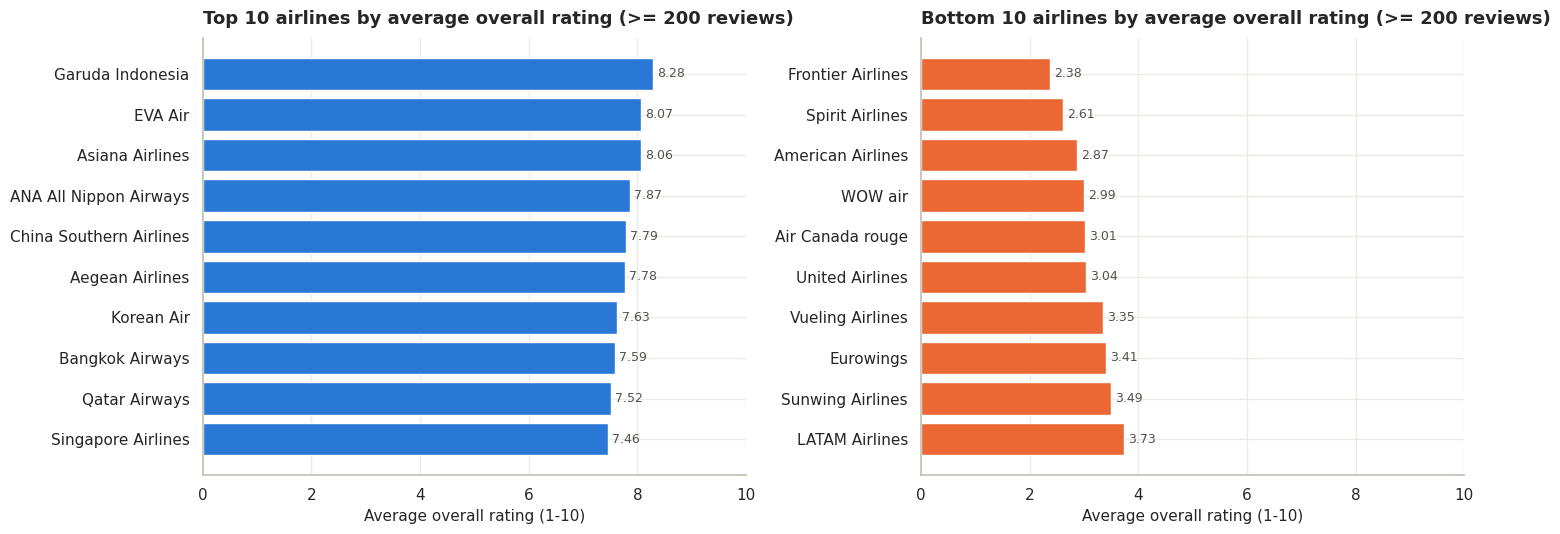

Airlines with >= 200 reviews: 73 of 81
IndiGo: rank 13 of 73 | avg overall 6.74 | recommendation rate 65.3% | reviews 262


,reviews,rec_rate,avg_overall
airline,,,
Garuda Indonesia,733,0.906,8.280
EVA Air,511,0.855,8.073
Asiana Airlines,432,0.847,8.063
ANA All Nippon Airways,461,0.835,7.868
China Southern Airlines,1686,0.862,7.792
Aegean Airlines,521,0.800,7.776
Korean Air,486,0.772,7.633
Bangkok Airways,351,0.755,7.594
Qatar Airways,1392,0.791,7.518


In [ ]:
# Chart - 1 visualization code
# Question: which airlines lead and lag on overall points? (only airlines with >= 200 reviews, for stable averages)
MIN_REVIEWS = 200
airline_stats = rec_rate(eda_df, 'airline', min_n=MIN_REVIEWS).sort_values('avg_overall', ascending=False)
top10, bottom10 = airline_stats.head(10), airline_stats.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].barh(top10.index[::-1], top10['avg_overall'][::-1], color=PRIMARY)
axes[1].barh(bottom10.index, bottom10['avg_overall'], color=HIGHLIGHT)
for ax, title in zip(axes, ['Top 10 airlines', 'Bottom 10 airlines']):
    label_bars(ax, fmt='{:.2f}')
    ax.set_xlim(0, 10)
    finish(ax, f'{title} by average overall rating (>= {MIN_REVIEWS} reviews)', 'Average overall rating (1-10)')
plt.tight_layout(); plt.show()

print(f'Airlines with >= {MIN_REVIEWS} reviews: {len(airline_stats)} of {eda_df["airline"].nunique()}')
indigo_rank = airline_stats.index.get_loc('IndiGo') + 1
print(f"IndiGo: rank {indigo_rank} of {len(airline_stats)} | avg overall {airline_stats.loc['IndiGo', 'avg_overall']:.2f} | "
      f"recommendation rate {airline_stats.loc['IndiGo', 'rec_rate']:.1%} | reviews {airline_stats.loc['IndiGo', 'reviews']}")
display(pd.concat([top10, bottom10]).round(3))

##### 1. Why did you pick the specific chart?

Horizontal bars rank named categories clearly. Two panels show both ends of the ranking. A minimum of 200 reviews avoids airlines whose average is based on very few reviews.

##### 2. What is/are the insight(s) found from the chart?

- **Top airlines** are mostly Asian full-service carriers: Garuda Indonesia (8.28), EVA Air (8.07), Asiana (8.06), ANA (7.87) and China Southern (7.79).
- **Bottom airlines** are mostly North American and European low-cost or large network carriers: Frontier (2.38), Spirit (2.61), American Airlines (2.87), WOW air (2.99) and Air Canada rouge (3.01).
- **IndiGo ranks 13th of 73** airlines (average overall 6.74, recommendation rate 65.3%, 262 reviews) - well above the dataset average.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** IndiGo is already in the top fifth of airlines on overall rating, which is a credible message for marketing.

**Negative / risk:** the gap to the leaders (about 1.5 points behind Garuda) shows room for improvement. Several low-cost carriers sit at the bottom, so IndiGo, as a low-cost carrier, must keep its service consistent to avoid the "budget airline" perception that drags those airlines down.

#### Chart - 2 - Distribution of the overall rating, split by recommendation

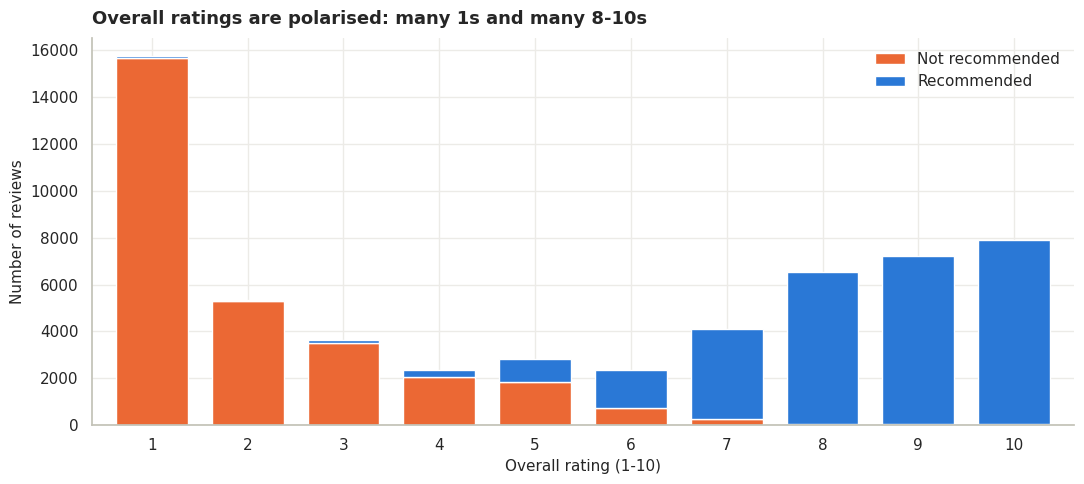

Share of reviews by overall rating:
overall
1.000    27.100
2.000     9.200
3.000     6.300
4.000     4.000
5.000     4.900
6.000     4.100
7.000     7.100
8.000    11.300
9.000    12.400
10.000   13.600
Name: proportion, dtype: float64
Missing overall: 1764


In [ ]:
# Chart - 2 visualization code
# Question: how are overall ratings distributed, and how do they split between recommenders and non-recommenders?
overall_split = pd.crosstab(eda_df['overall'], eda_df['recommended'])
fig, ax = plt.subplots(figsize=(11, 5))
overall_split[[0, 1]].plot(kind='bar', stacked=True, color=[NO_COLOR, YES_COLOR], width=0.75, ax=ax, edgecolor='white')
ax.legend(['Not recommended', 'Recommended'], frameon=False)
ax.set_xticklabels([int(x) for x in overall_split.index], rotation=0)
finish(ax, 'Overall ratings are polarised: many 1s and many 8-10s', 'Overall rating (1-10)', 'Number of reviews', legend=True)
plt.tight_layout(); plt.show()

print('Share of reviews by overall rating:'); print((eda_df['overall'].value_counts(normalize=True).sort_index() * 100).round(1))
print('Missing overall:', eda_df['overall'].isna().sum())

##### 1. Why did you pick the specific chart?

A stacked bar chart shows the distribution of a discrete 1-10 score and, in the same bar, how many of those reviewers recommended the airline.

##### 2. What is/are the insight(s) found from the chart?

- Ratings are **polarised (U-shaped)**: a score of **1 is the most common (27.1% of reviews)**, and scores of 8, 9 and 10 together make up about 37%. Middle scores (3-6) are less common.
- The colour split is almost perfect: low scores are almost all "No", high scores are almost all "Yes".

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the clear split means the overall score is a reliable signal of advocacy.

**Negative:** polarised reviews mean that a bad experience tends to produce a very negative review (score 1), which is the most damaging type of word-of-mouth. Preventing failures may matter as much as delighting customers.

#### Chart - 3 - Recommendation rate by overall rating

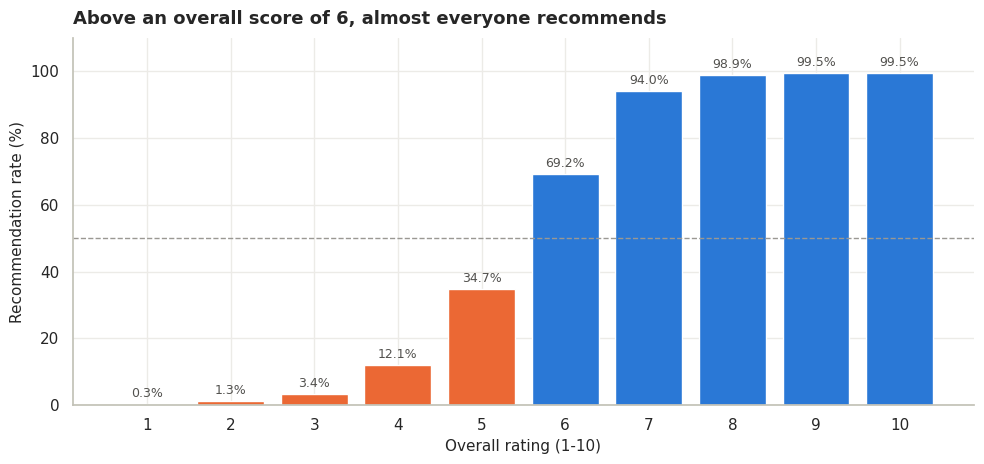

overall
1.000     0.300
2.000     1.300
3.000     3.400
4.000    12.100
5.000    34.700
6.000    69.200
7.000    94.000
8.000    98.900
9.000    99.500
10.000   99.500
Name: recommended, dtype: float64
Spearman correlation overall vs recommended: 0.858


In [ ]:
# Chart - 3 visualization code
# Question: how strongly does the overall rating relate to recommendation?
overall_rate = eda_df.groupby('overall')['recommended'].mean() * 100
fig, ax = plt.subplots(figsize=(10, 4.8))
bars = ax.bar(overall_rate.index.astype(int).astype(str), overall_rate.values,
              color=[YES_COLOR if v >= 50 else NO_COLOR for v in overall_rate.values])
label_bars(ax, fmt='{:.1f}%')
ax.axhline(50, color=NEUTRAL, linestyle='--', linewidth=1)
ax.set_ylim(0, 110)
finish(ax, 'Above an overall score of 6, almost everyone recommends', 'Overall rating (1-10)', 'Recommendation rate (%)')
plt.tight_layout(); plt.show()
print(overall_rate.round(1))
print('Spearman correlation overall vs recommended:', round(eda_df[['overall', 'recommended']].corr(method='spearman').iloc[0, 1], 3))

##### 1. Why did you pick the specific chart?

A bar chart of the recommendation rate at each score shows the shape of the relationship directly - whether it is gradual or a sharp switch.

##### 2. What is/are the insight(s) found from the chart?

- The rate jumps from **34.7% at a score of 5** to **69.2% at 6** and **94.0% at 7**; at 8 and above it is **98.9-99.5%**. At scores 1-3 it is **0.3-3.4%**.
- Spearman correlation between `overall` and `recommended` is **0.86**.
- This confirms **H4**: the overall rating behaves almost like a restatement of the recommendation decision, because both are given by the same passenger at the same moment.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** an overall score of 7 or higher is a near-certain advocate; this threshold is useful for marketing (e.g., inviting such passengers to share reviews).

**Caution for modelling:** because `overall` almost "gives away" the answer, a model built on it would look excellent but would not explain *what to fix*. Section 10 therefore keeps `overall` out of the main model and uses it only as a benchmark.

#### Chart - 4 - Distribution of the six service ratings

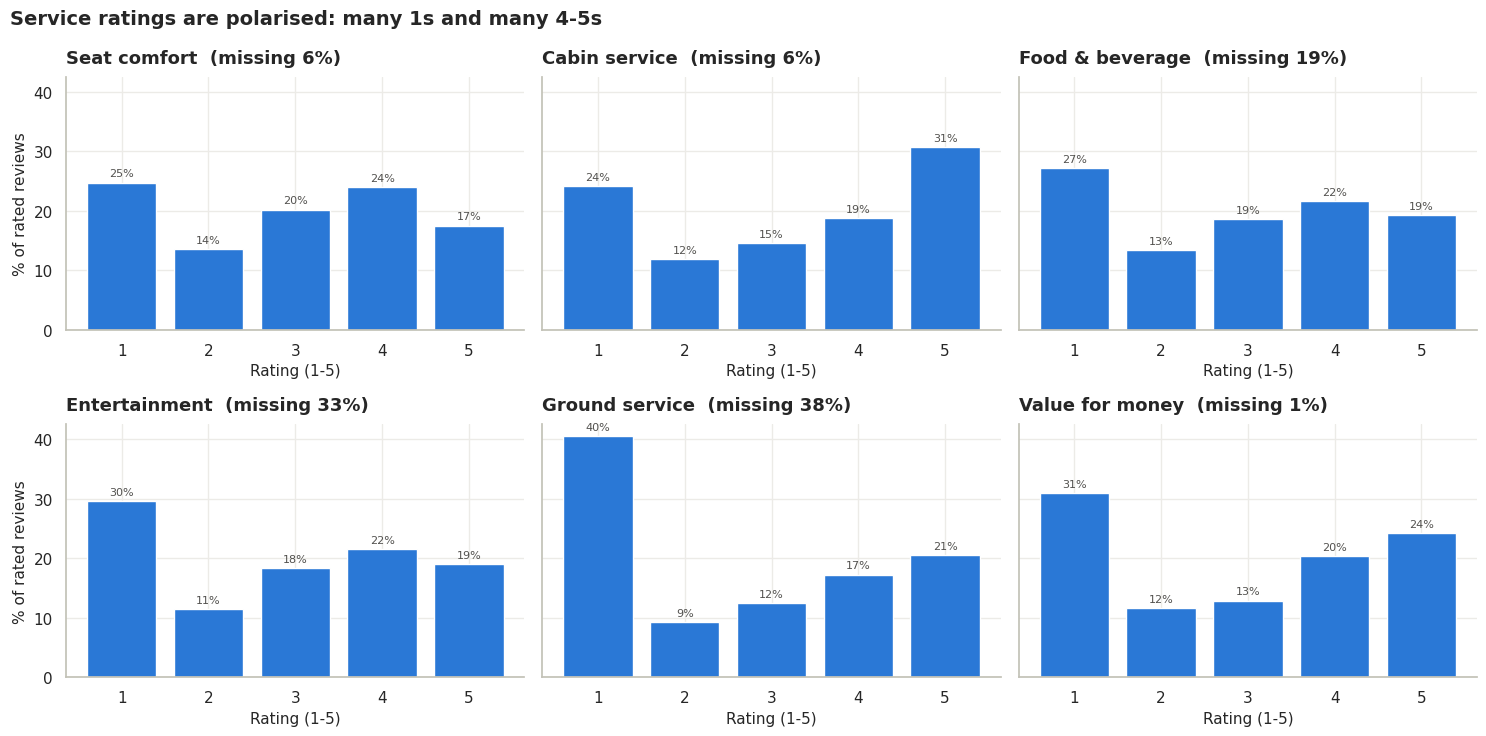

,count,mean,std,min,25%,50%,75%,max
seat_comfort,"56,211.000",2.960,1.440,1.000,2.000,3.000,4.000,5.000
cabin_service,"56,240.000",3.200,1.570,1.000,2.000,3.000,5.000,5.000
food_bev,"48,341.000",2.930,1.480,1.000,1.000,3.000,4.000,5.000
entertainment,"40,230.000",2.890,1.500,1.000,1.000,3.000,4.000,5.000
ground_service,"37,169.000",2.680,1.610,1.000,1.000,3.000,4.000,5.000
value_for_money,"59,327.000",2.950,1.590,1.000,1.000,3.000,4.000,5.000


In [ ]:
# Chart - 4 visualization code
# Question: how do passengers rate each service area, and how much of each rating is missing?
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), sharey=True)
for ax, col in zip(axes.flat, RATING_COLS):
    counts = eda_df[col].value_counts(normalize=True).sort_index() * 100
    ax.bar(counts.index.astype(int).astype(str), counts.values, color=PRIMARY)
    label_bars(ax, fmt='{:.0f}%', fontsize=8)
    finish(ax, f'{RATING_LABELS[col]}  (missing {eda_df[col].isna().mean():.0%})', 'Rating (1-5)',
           '% of rated reviews' if col in ['seat_comfort', 'entertainment'] else '')
plt.suptitle('Service ratings are polarised: many 1s and many 4-5s', fontsize=14, fontweight='bold', x=0.01, ha='left')
plt.tight_layout(); plt.show()
display(eda_df[RATING_COLS].describe().T.round(2))

##### 1. Why did you pick the specific chart?

Small multiples (one panel per attribute on the same y-scale) make it easy to compare six distributions side by side. Percentages are used because each attribute has a different number of missing values.

##### 2. What is/are the insight(s) found from the chart?

- For five of the six attributes, **1 is the most common score**; the exception is **cabin service**, where **5 is the most common (31%)**. Averages sit between **2.68 and 3.20** on a 1-5 scale.
- **Ground service** has the lowest average (2.68), the highest share of 1-ratings (40%) and the most missing values (38%); **entertainment** is also frequently missing (33%).
- Ratings are polarised, like the overall score.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** each attribute has a wide spread of ratings, which gives the model enough variation to learn from.

**Negative:** the large share of 1-ratings in ground service (40%) and value for money (31%) shows widespread dissatisfaction in these areas across the industry - and an opportunity for an airline that gets them right.

#### Chart - 5 - Recommendation rate at each service-rating level

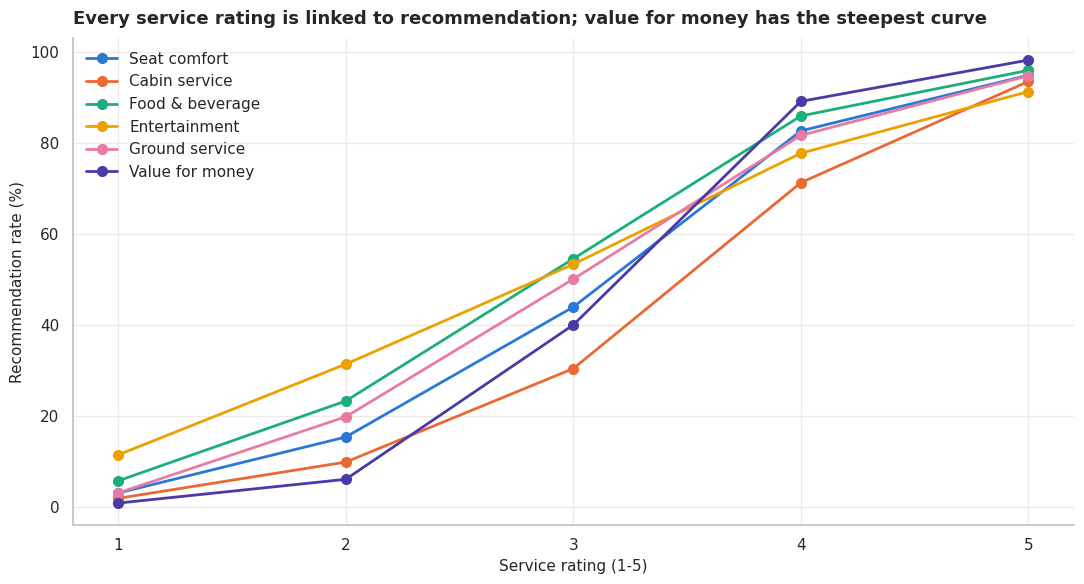

,1.000,2.000,3.000,4.000,5.000,jump 1 -> 5 (pts)
Value for money,0.900,6.100,40.000,89.100,98.100,97.200
Seat comfort,3.100,15.400,44.000,82.600,94.800,91.700
Ground service,3.100,19.800,50.100,81.600,94.700,91.600
Cabin service,2.000,9.900,30.400,71.200,93.500,91.500
Food & beverage,5.800,23.300,54.500,85.900,95.900,90.100
Entertainment,11.500,31.400,53.300,77.700,91.200,79.700


In [ ]:
# Chart - 5 visualization code
# Question: which service attributes are most strongly associated with recommendation?
fig, ax = plt.subplots(figsize=(11, 6))
rate_by_level = {}
for color, col in zip(SERIES, RATING_COLS):
    rate = eda_df.groupby(col)['recommended'].mean() * 100
    rate_by_level[RATING_LABELS[col]] = rate
    ax.plot(rate.index, rate.values, marker='o', markersize=7, linewidth=2, color=color, label=RATING_LABELS[col])
ax.set_xticks([1, 2, 3, 4, 5])
ax.legend(frameon=False, loc='upper left')
finish(ax, 'Every service rating is linked to recommendation; value for money has the steepest curve',
       'Service rating (1-5)', 'Recommendation rate (%)', legend=True)
plt.tight_layout(); plt.show()
rate_table = pd.DataFrame(rate_by_level).T.round(1)
rate_table['jump 1 -> 5 (pts)'] = rate_table[5.0] - rate_table[1.0]
display(rate_table.sort_values('jump 1 -> 5 (pts)', ascending=False))

##### 1. Why did you pick the specific chart?

A line chart with one line per attribute shows how the recommendation rate rises as each rating improves, so the steepness of each curve can be compared directly.

##### 2. What is/are the insight(s) found from the chart?

- Every attribute shows a strong upward pattern.
- **Value for money** has the steepest curve: **0.9%** of passengers recommend at a rating of 1 vs **98.1%** at 5; a rating of 4 already gives **89.1%**.
- **Cabin service** (2.0% -> 93.5%), **seat comfort** (3.1% -> 94.8%) and **ground service** (3.1% -> 94.7%) are similarly strong.
- **Entertainment** has the flattest curve (11.5% -> 91.2%): passengers who rate entertainment poorly still sometimes recommend.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** value for money, cabin service, seat comfort and ground service are the clearest levers. Moving passengers from a rating of 3 to 4 on value for money is associated with a jump from 40.0% to 89.1% recommendation.

**Negative:** a single poor rating (1-2) in value for money or cabin service is associated with very low advocacy (below 10%). These are "deal-breakers" to protect.

#### Chart - 6 - Average service ratings: recommenders vs non-recommenders

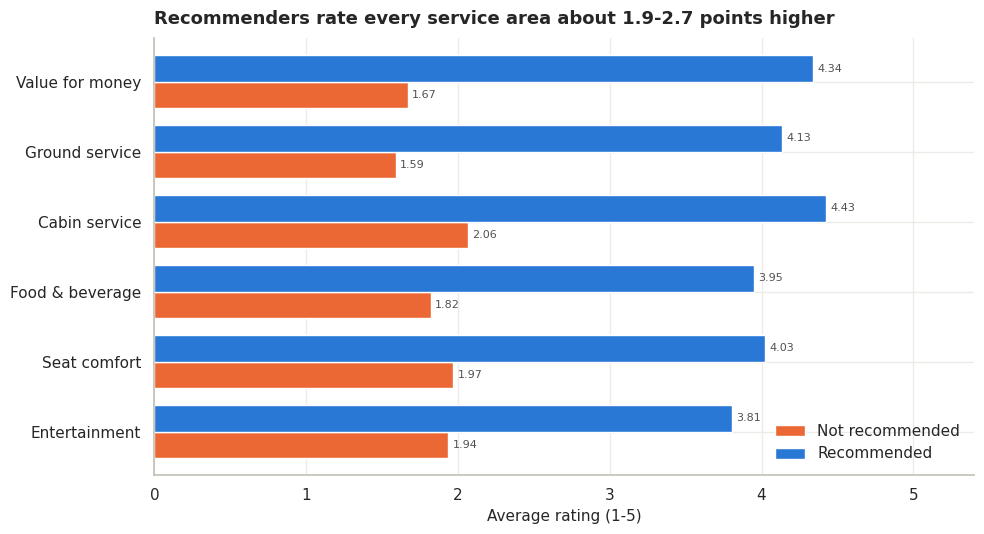

                 Not recommended  Recommended   gap
Entertainment              1.940        3.810 1.870
Seat comfort               1.970        4.030 2.060
Food & beverage            1.820        3.950 2.130
Cabin service              2.060        4.430 2.360
Ground service             1.590        4.130 2.540
Value for money            1.670        4.340 2.670


In [ ]:
# Chart - 6 visualization code
# Question: how big is the rating gap between passengers who recommend and those who do not?
means = eda_df.groupby('recommended')[RATING_COLS].mean().T
means.columns = ['Not recommended', 'Recommended']
means.index = [RATING_LABELS[c] for c in means.index]
means['gap'] = means['Recommended'] - means['Not recommended']
means = means.sort_values('gap')

fig, ax = plt.subplots(figsize=(10, 5.5))
means[['Not recommended', 'Recommended']].plot(kind='barh', color=[NO_COLOR, YES_COLOR], width=0.75, ax=ax, edgecolor='white')
label_bars(ax, fmt='{:.2f}', fontsize=8)
ax.set_xlim(0, 5.4)
ax.legend(frameon=False, loc='lower right')
finish(ax, 'Recommenders rate every service area about 1.9-2.7 points higher', 'Average rating (1-5)', '', legend=True)
plt.tight_layout(); plt.show()
print(means.round(2))

##### 1. Why did you pick the specific chart?

Grouped horizontal bars compare two groups across six attributes at once; sorting by the gap puts the biggest difference at the top.

##### 2. What is/are the insight(s) found from the chart?

- The largest gaps are in **value for money (2.67 points)**, **ground service (2.54)** and **cabin service (2.36)**; the smallest gap is in **entertainment (1.87)**.
- Non-recommenders average below 2 on most attributes, while recommenders average around 4.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the size of the gap confirms that service quality and perceived value separate advocates from detractors.

**Negative:** non-recommenders give low scores across *all* areas, not just one - a bad trip tends to be bad "everywhere" in the passenger's memory. Fixing a single area may not be enough on its own.

#### Chart - 7 - Traveller type: recommendation rate and average overall rating

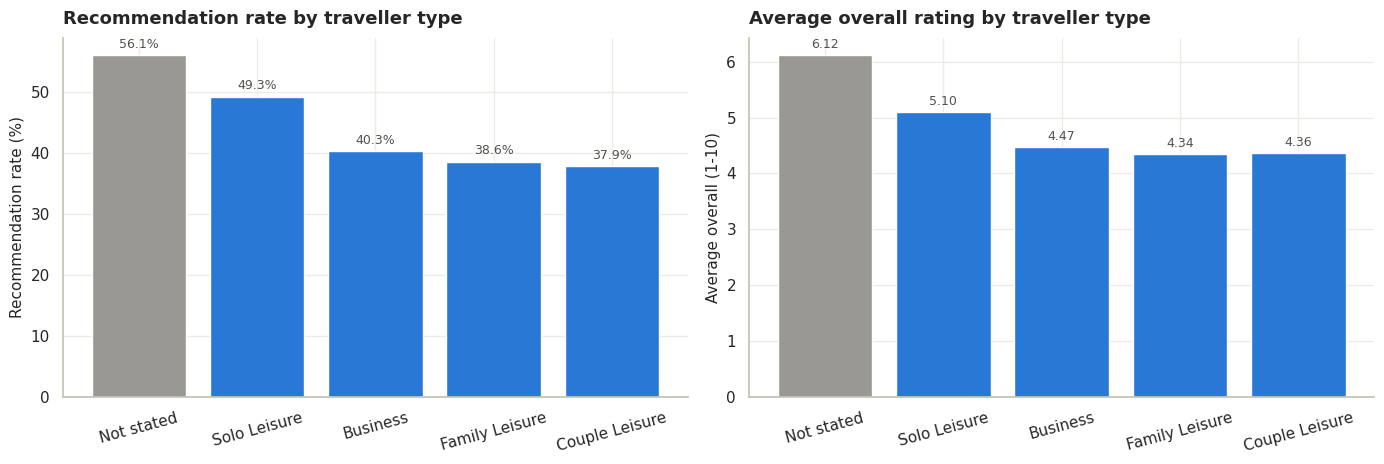

,reviews,rec_rate,avg_overall
traveller_type,,,
Not stated,22222,0.561,6.119
Solo Leisure,13934,0.493,5.102
Business,6764,0.403,4.468
Family Leisure,7142,0.386,4.341
Couple Leisure,9699,0.379,4.362


In [ ]:
# Chart - 7 visualization code
# Question: do business or leisure travellers recommend more?
tt = rec_rate(eda_df.assign(traveller_type=eda_df['traveller_type'].fillna('Not stated')), 'traveller_type')
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].bar(tt.index, tt['rec_rate'] * 100, color=[NEUTRAL if i == 'Not stated' else PRIMARY for i in tt.index])
label_bars(axes[0], fmt='{:.1f}%')
finish(axes[0], 'Recommendation rate by traveller type', '', 'Recommendation rate (%)')
axes[1].bar(tt.index, tt['avg_overall'], color=[NEUTRAL if i == 'Not stated' else PRIMARY for i in tt.index])
label_bars(axes[1], fmt='{:.2f}')
finish(axes[1], 'Average overall rating by traveller type', '', 'Average overall (1-10)')
for ax in axes: ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()
display(tt.round(3))

##### 1. Why did you pick the specific chart?

Bar charts compare a small number of categories. Two panels show both the recommendation rate and the average overall rating, so we can check that they tell the same story.

##### 2. What is/are the insight(s) found from the chart?

- Among passengers who stated their type, **Solo Leisure** travellers recommend most (**49.3%**); **Business (40.3%)**, **Family Leisure (38.6%)** and **Couple Leisure (37.9%)** are lower.
- Reviews with no traveller type ("Not stated", mostly older reviews before the field existed) have the highest rate (56.1%) - an effect of review **era**, not of the traveller (see Chart 11 and Section 7).
- **H2 (business travellers recommend more) is not supported** - business travellers are below solo leisure travellers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** solo leisure travellers are the most positive segment and natural candidates for referral or review campaigns.

**Negative:** business travellers - typically high-value, frequent flyers - are less likely to recommend. Their expectations (punctuality, ground processes, comfort) are not being met as well, which is a risk for corporate revenue.

#### Chart - 8 - Recommendation rate by cabin class

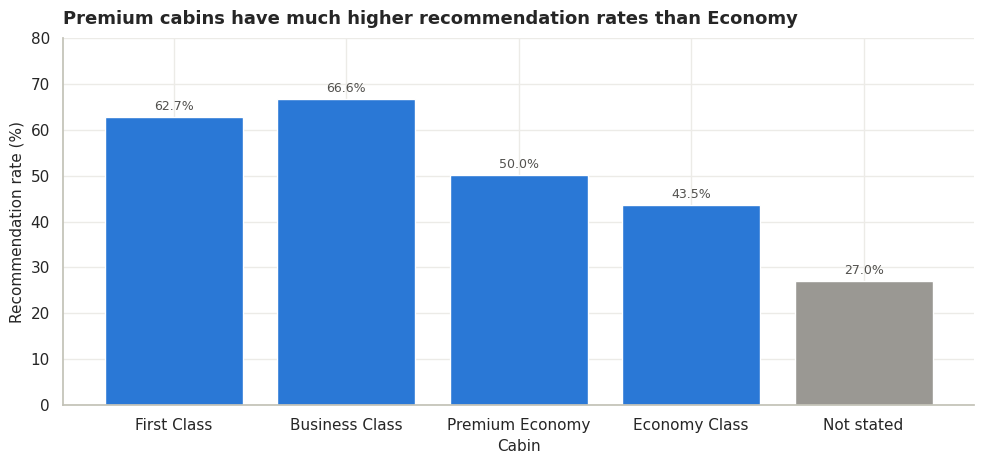

,reviews,rec_rate,avg_overall
cabin,,,
First Class,1532,0.627,6.406
Business Class,9590,0.666,6.603
Premium Economy,2412,0.500,5.387
Economy Class,45170,0.435,4.827
Not stated,1057,0.270,4.061


In [ ]:
# Chart - 8 visualization code
# Question: do premium-cabin passengers recommend more than economy passengers?
cab = rec_rate(eda_df.assign(cabin=eda_df['cabin'].fillna('Not stated')), 'cabin')
order = ['First Class', 'Business Class', 'Premium Economy', 'Economy Class', 'Not stated']
cab = cab.loc[[c for c in order if c in cab.index]]
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(cab.index, cab['rec_rate'] * 100, color=[NEUTRAL if i == 'Not stated' else PRIMARY for i in cab.index])
label_bars(ax, fmt='{:.1f}%')
ax.set_ylim(0, 80)
finish(ax, 'Premium cabins have much higher recommendation rates than Economy', 'Cabin', 'Recommendation rate (%)')
plt.tight_layout(); plt.show()
display(cab.round(3))

##### 1. Why did you pick the specific chart?

A bar chart compares the recommendation rate across the four cabin classes in their natural order (most to least premium).

##### 2. What is/are the insight(s) found from the chart?

- **Business Class (66.6%)** and **First Class (62.7%)** have the highest recommendation rates; **Premium Economy** is 50.0% and **Economy is only 43.5%**.
- Economy accounts for **45,170 of 59,761 reviews (75.6%)**, so it dominates the dataset.
- **H5 (premium cabins recommend more) is supported.**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the premium experience works - more space and service lead to more advocacy.

**Negative / relevant to IndiGo:** IndiGo's reviews are **100% Economy**. Economy passengers are the hardest segment to turn into promoters, so IndiGo competes in the toughest segment and must win on value and service consistency rather than on cabin luxury.

#### Chart - 9 - Traveller type x cabin: recommendation rate (heatmap)

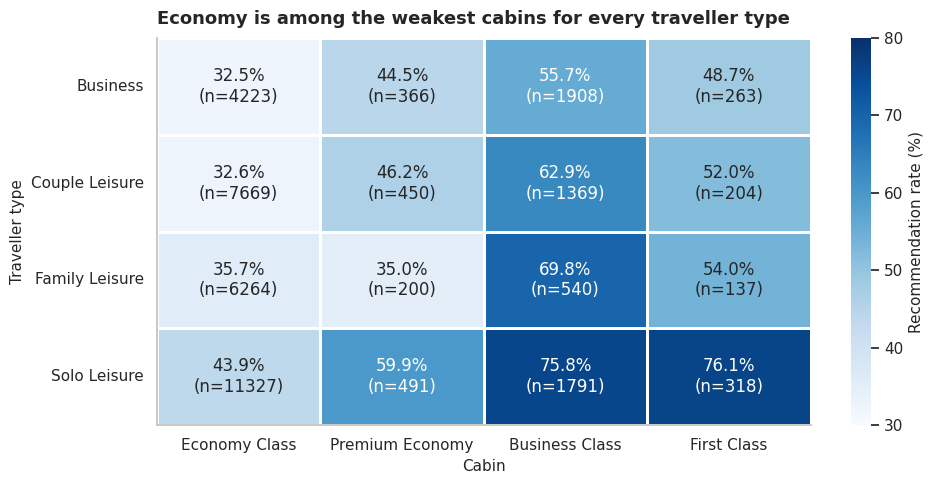

In [ ]:
# Chart - 9 visualization code
# Question: does the cabin effect hold for every traveller type? (multivariate: traveller type x cabin x target)
seg = eda_df.dropna(subset=['traveller_type', 'cabin'])
heat = pd.crosstab(seg['traveller_type'], seg['cabin'], values=seg['recommended'], aggfunc='mean') * 100
counts = pd.crosstab(seg['traveller_type'], seg['cabin'])
heat = heat[['Economy Class', 'Premium Economy', 'Business Class', 'First Class']]
annot = heat.round(1).astype(str) + '%\n(n=' + counts[heat.columns].astype(str) + ')'
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heat, annot=annot, fmt='', cmap='Blues', vmin=30, vmax=80, linewidths=1, linecolor='white',
            cbar_kws={'label': 'Recommendation rate (%)'}, ax=ax)
finish(ax, 'Economy is among the weakest cabins for every traveller type', 'Cabin', 'Traveller type')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A heatmap shows a two-way table (traveller type x cabin) with colour for the recommendation rate; cell labels include the number of reviews so small cells can be judged carefully.

##### 2. What is/are the insight(s) found from the chart?

- **Economy has the lowest or near-lowest rate for every traveller type** (32.5%-43.9%); the only exception is Family Leisure, where Premium Economy (35.0%, only 200 reviews) is slightly below Economy (35.7%).
- The best segment is **Solo Leisure in Business Class (75.8%)** and **Solo Leisure in First Class (76.1%)**.
- **Business travellers in Economy** (32.5%, n=4,223) and **Couple Leisure in Economy** (32.6%, n=7,669) are the least satisfied large segments.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the analysis pinpoints the segments with the largest gap to close - economy-class couples, families and business travellers.

**Negative:** business travellers flying economy are the least likely to recommend; for an all-economy airline like IndiGo, this is a key segment where competitors with premium cabins have an advantage.

#### Chart - 10 - Recommendation rate by aircraft type

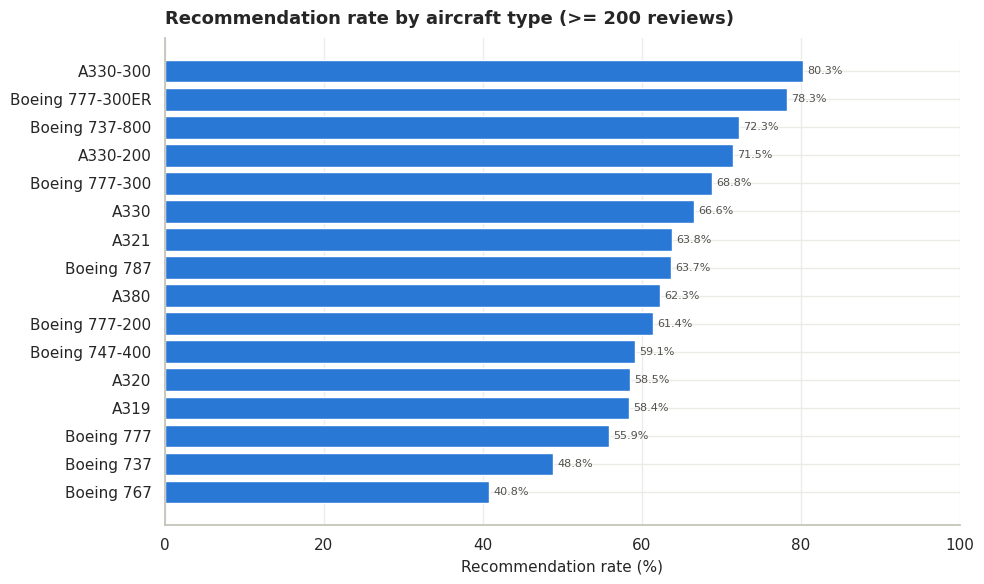

Reviews with aircraft recorded: 18,487 (30.9%) | distinct spellings: 2,088


,reviews,rec_rate,avg_overall
aircraft,,,
A330-300,436,0.803,7.337
Boeing 777-300ER,737,0.783,7.365
Boeing 737-800,1021,0.723,6.732
A330-200,319,0.715,6.624
Boeing 777-300,558,0.688,6.763
A330,974,0.666,6.484
A321,649,0.638,6.114
Boeing 787,833,0.637,6.300
A380,1109,0.623,6.414


In [ ]:
# Chart - 10 visualization code
# Question: are there differences across aircraft types? (only aircraft names with >= 200 reviews)
aircraft_stats = rec_rate(eda_df.dropna(subset=['aircraft']), 'aircraft', min_n=200)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(aircraft_stats.index[::-1], aircraft_stats['rec_rate'][::-1] * 100, color=PRIMARY)
label_bars(ax, fmt='{:.1f}%', fontsize=8)
ax.set_xlim(0, 100)
finish(ax, 'Recommendation rate by aircraft type (>= 200 reviews)', 'Recommendation rate (%)', '')
plt.tight_layout(); plt.show()
print(f"Reviews with aircraft recorded: {eda_df['aircraft'].notna().sum():,} ({eda_df['aircraft'].notna().mean():.1%}) | "
      f"distinct spellings: {eda_df['aircraft'].nunique():,}")
display(aircraft_stats.round(3))

##### 1. Why did you pick the specific chart?

A sorted horizontal bar chart ranks aircraft types by recommendation rate; a 200-review minimum keeps the comparison reliable.

##### 2. What is/are the insight(s) found from the chart?

- Rates range from **80.3% (A330-300)** and **78.3% (Boeing 777-300ER)** down to **48.8% (Boeing 737)** and **40.8% (Boeing 767)**.
- **A320** - the aircraft type most used by IndiGo - has the most reviews (2,130) and a rate of **58.5%**.
- However, aircraft is recorded for only **30.9%** of reviews and has **2,088 different spellings** (e.g., "A320", "Airbus A320", "A320neo"), and aircraft type is mixed up with airline and route length (wide-bodies fly long-haul, often in full-service airlines).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** wide-body, long-haul aircraft are associated with higher advocacy, which is useful context for benchmarking.

**Negative / caution:** because of 69% missing values and inconsistent naming, aircraft is **not used in the model** - differences here mostly reflect the airline and type of route, not the aircraft itself.

#### Chart - 11 - Reviews and recommendation rate over time

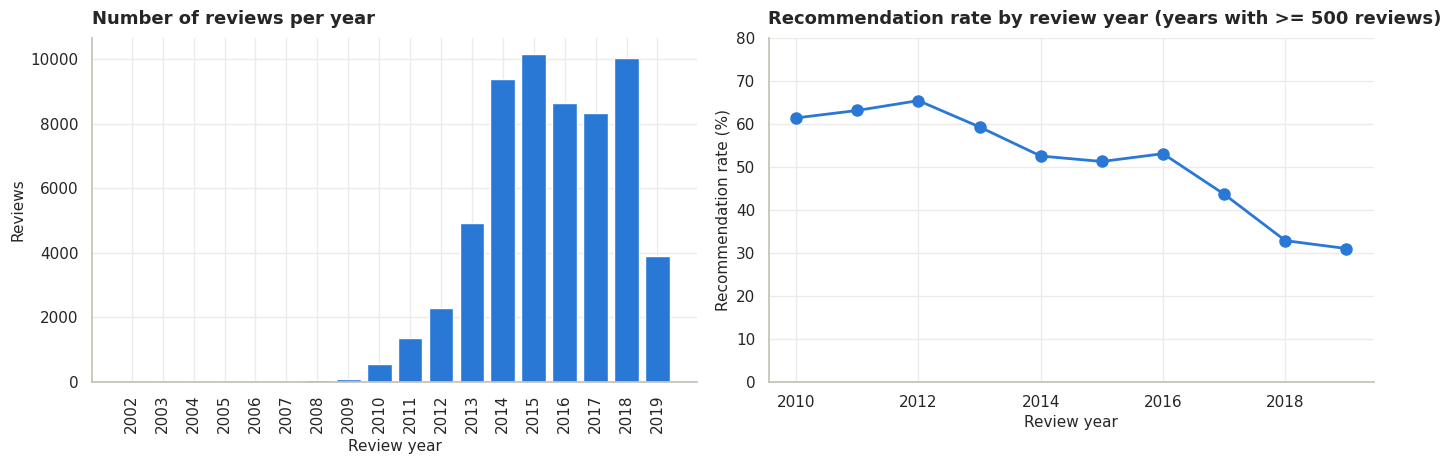

review_year,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
reviews,2.000,4.000,8.000,7.000,34.000,21.000,35.000,92.000,554.000,"1,358.000","2,269.000","4,931.000","9,376.000","10,155.000","8,633.000","8,331.000","10,044.000","3,907.000"
rec_rate,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.467,0.614,0.631,0.654,0.593,0.525,0.512,0.531,0.436,0.328,0.310


In [ ]:
# Chart - 11 visualization code
# Question: has the recommendation rate changed over the years?
eda_df['review_year'] = eda_df['review_date_dt'].dt.year
yearly = eda_df.groupby('review_year').agg(reviews=('recommended', 'size'), rec_rate=('recommended', 'mean'))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].bar(yearly.index.astype(str), yearly['reviews'], color=PRIMARY)
finish(axes[0], 'Number of reviews per year', 'Review year', 'Reviews')
axes[0].tick_params(axis='x', rotation=90)
recent = yearly[yearly['reviews'] >= 500]     # only years with enough reviews for a stable rate
axes[1].plot(recent.index, recent['rec_rate'] * 100, marker='o', markersize=8, linewidth=2, color=PRIMARY)
axes[1].set_ylim(0, 80)
finish(axes[1], 'Recommendation rate by review year (years with >= 500 reviews)', 'Review year', 'Recommendation rate (%)')
plt.tight_layout(); plt.show()
display(yearly.round(3).T)

##### 1. Why did you pick the specific chart?

A bar chart shows review volume per year; a line chart shows the trend in the recommendation rate. They are drawn as two panels because they use different units.

##### 2. What is/are the insight(s) found from the chart?

- Most reviews were written between **2013 and 2018**; only a few hundred exist before 2010.
- The recommendation rate **peaked around 2012 (65.4%)** and has **fallen steadily since 2016**, to **32.8% in 2018** and **31.0% in 2019** (partial year).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** tracking the rate over time is a simple KPI for customer experience programmes.

**Negative:** the industry-wide decline in recent years means passengers are becoming harder to please (or more negative reviewers are posting). Part of the change may come from how the review website changed over time (Section 7), so the trend should be read with care. `review_year` is included in the model to account for this era effect.

#### Chart - 12 - Airline-level value for money vs recommendation rate

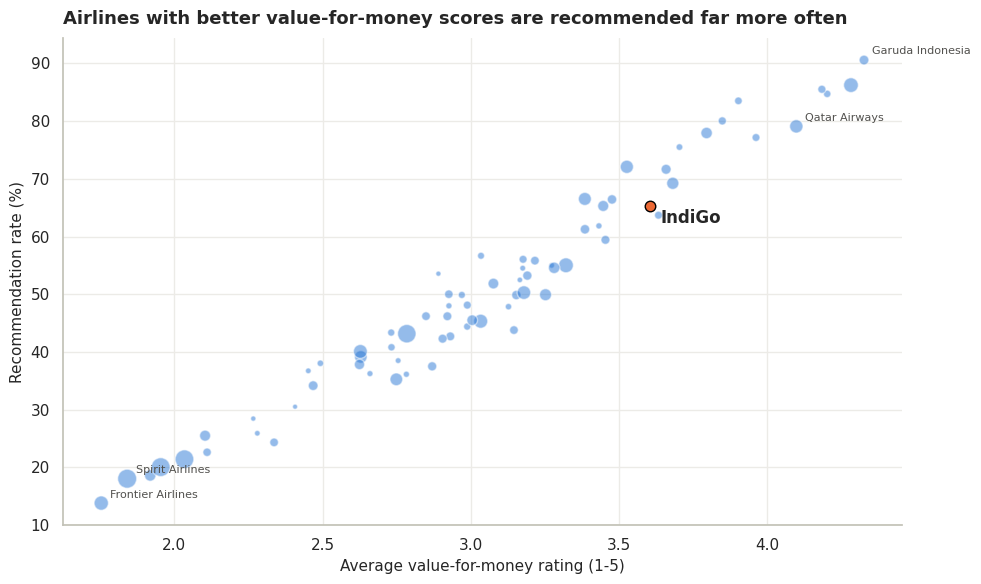

Correlation (airline level, n=73): 0.98


In [ ]:
# Chart - 12 visualization code
# Question: at the airline level, does value for money track recommendation? Where does IndiGo sit?
air = (eda_df.groupby('airline')
             .agg(reviews=('recommended', 'size'), rec_rate=('recommended', 'mean'), vfm=('value_for_money', 'mean'))
             .query('reviews >= 200'))
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(air['vfm'], air['rec_rate'] * 100, s=air['reviews'] / 15, color=PRIMARY, alpha=0.5, edgecolor='white')
ig = air.loc['IndiGo']
ax.scatter(ig['vfm'], ig['rec_rate'] * 100, s=ig['reviews'] / 15 + 40, color=HIGHLIGHT, edgecolor='black', zorder=3)
ax.annotate('IndiGo', (ig['vfm'], ig['rec_rate'] * 100), xytext=(8, -12), textcoords='offset points', fontweight='bold')
for name in ['Garuda Indonesia', 'Frontier Airlines', 'Spirit Airlines', 'Qatar Airways']:
    ax.annotate(name, (air.loc[name, 'vfm'], air.loc[name, 'rec_rate'] * 100), xytext=(6, 4), textcoords='offset points', fontsize=8, color=MUTED)
finish(ax, 'Airlines with better value-for-money scores are recommended far more often',
       'Average value-for-money rating (1-5)', 'Recommendation rate (%)')
plt.tight_layout(); plt.show()
print(f"Correlation (airline level, n={len(air)}): {air['vfm'].corr(air['rec_rate']):.2f}")

##### 1. Why did you pick the specific chart?

A scatter plot shows the relationship between two numeric airline-level measures; bubble size shows the number of reviews, and IndiGo is highlighted.

##### 2. What is/are the insight(s) found from the chart?

- At the airline level, average value-for-money rating and recommendation rate are almost perfectly correlated (**r = 0.98** across 73 airlines).
- **IndiGo** sits in the upper-middle of the cloud (value for money **3.60**, recommendation **65.3%**), above the low-cost carriers at the bottom-left (Frontier, Spirit).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** this strongly supports **H1** - value for money is the clearest airline-level driver of advocacy, and IndiGo's low-cost positioning is an advantage when passengers feel they got good value.

**Negative:** low-cost carriers with poor value perception (Spirit, Frontier) show that "cheap" does not automatically mean "good value" - hidden fees or poor service can destroy value perception.

#### Chart - 13 - Airlines leading in food & beverage scores

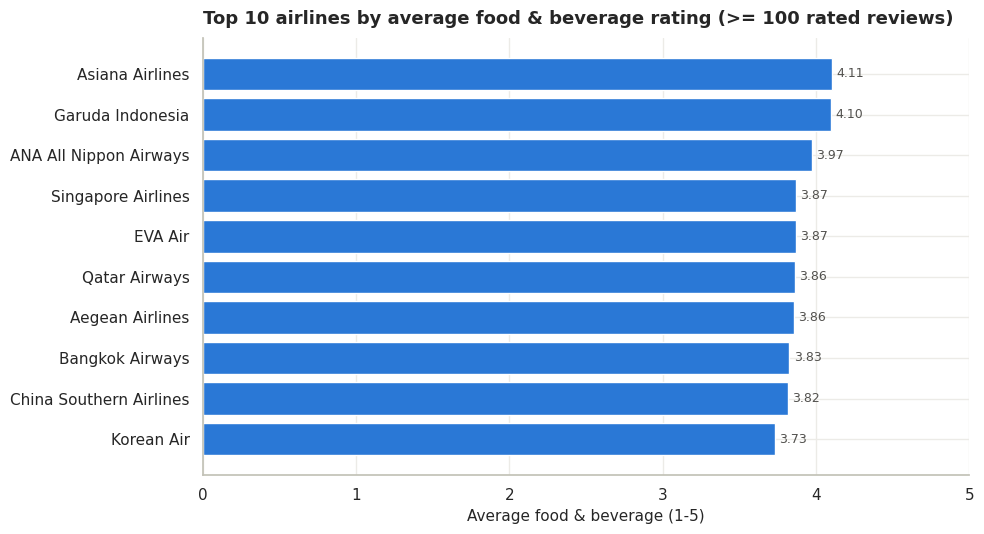

IndiGo food & beverage: 3.11 (rank 29 of 73, 140 rated reviews) | dataset average 2.93


In [ ]:
# Chart - 13 visualization code
# Question: which airline leads in food & beverage scores? Where does IndiGo stand?
fb = (eda_df.groupby('airline').agg(reviews=('food_bev', 'count'), avg_food_bev=('food_bev', 'mean'))
            .query('reviews >= 100').sort_values('avg_food_bev', ascending=False))
top_fb = fb.head(10)
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(top_fb.index[::-1], top_fb['avg_food_bev'][::-1], color=PRIMARY)
label_bars(ax, fmt='{:.2f}')
ax.set_xlim(0, 5)
finish(ax, 'Top 10 airlines by average food & beverage rating (>= 100 rated reviews)', 'Average food & beverage (1-5)', '')
plt.tight_layout(); plt.show()
print(f"IndiGo food & beverage: {fb.loc['IndiGo', 'avg_food_bev']:.2f} (rank {fb.index.get_loc('IndiGo') + 1} of {len(fb)}, "
      f"{int(fb.loc['IndiGo', 'reviews'])} rated reviews) | dataset average {eda_df['food_bev'].mean():.2f}")

##### 1. Why did you pick the specific chart?

A ranked horizontal bar chart answers "who leads" at a glance (one of the questions in the project architecture).

##### 2. What is/are the insight(s) found from the chart?

- **Asiana Airlines (4.11)** and **Garuda Indonesia (4.10)** lead food & beverage, followed by ANA (3.97), Singapore Airlines and EVA Air (3.87).
- The leaders are the same Asian full-service airlines that top the overall ranking (Chart 1).
- **IndiGo scores 3.11** (rank 29 of 73, based on 140 rated reviews) - above the dataset average of 2.93 but well below the full-service leaders.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** food quality is part of the premium experience that the top airlines deliver consistently.

**Negative:** for a low-cost carrier, catering is a cost item. Chart 5 shows food & beverage matters, but less than value for money and cabin service, so heavy investment here may not be the most efficient lever for IndiGo.

#### Chart - 14 - IndiGo vs all airlines: service ratings

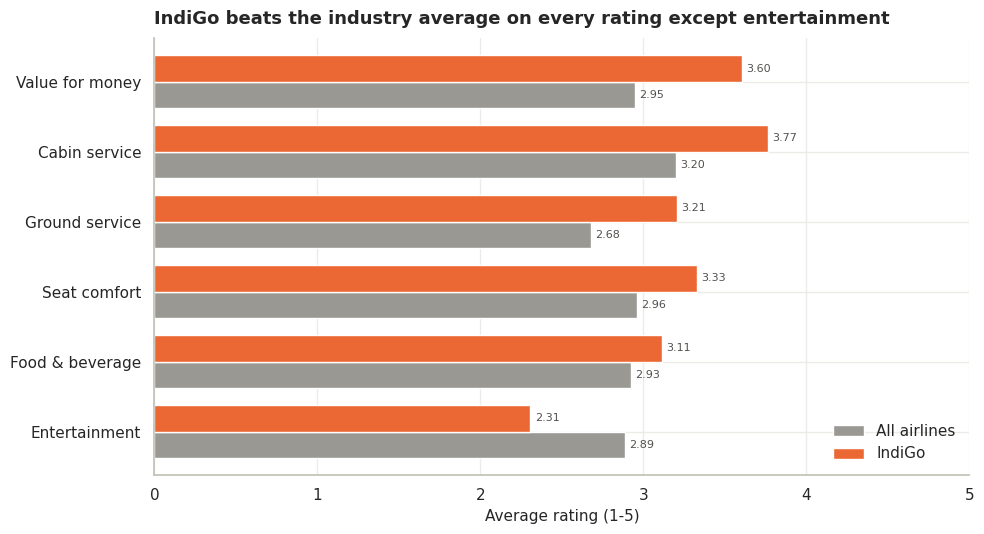

IndiGo reviews: 262 | recommendation rate 65.3% vs 47.7% overall
IndiGo cabin mix: {'Economy Class': 262}


,IndiGo,All airlines,IndiGo rated (n),difference
Entertainment,2.310,2.890,52,-0.580
Food & beverage,3.110,2.930,140,0.190
Seat comfort,3.330,2.960,218,0.370
Ground service,3.210,2.680,155,0.530
Cabin service,3.770,3.200,219,0.570
Value for money,3.600,2.950,262,0.650


In [ ]:
# Chart - 14 visualization code
# Question: where is IndiGo stronger or weaker than the industry average?
indigo = eda_df[eda_df['airline'] == 'IndiGo']
compare = pd.DataFrame({'IndiGo': indigo[RATING_COLS].mean(), 'All airlines': eda_df[RATING_COLS].mean()})
compare['IndiGo rated (n)'] = indigo[RATING_COLS].count()
compare.index = [RATING_LABELS[c] for c in compare.index]
compare['difference'] = compare['IndiGo'] - compare['All airlines']
compare = compare.sort_values('difference')

fig, ax = plt.subplots(figsize=(10, 5.5))
compare[['All airlines', 'IndiGo']].plot(kind='barh', color=[NEUTRAL, HIGHLIGHT], width=0.75, ax=ax, edgecolor='white')
label_bars(ax, fmt='{:.2f}', fontsize=8)
ax.set_xlim(0, 5)
ax.legend(frameon=False, loc='lower right')
finish(ax, 'IndiGo beats the industry average on every rating except entertainment', 'Average rating (1-5)', '', legend=True)
plt.tight_layout(); plt.show()
print(f"IndiGo reviews: {len(indigo)} | recommendation rate {indigo['recommended'].mean():.1%} vs {eda_df['recommended'].mean():.1%} overall")
print(f"IndiGo cabin mix: {indigo['cabin'].value_counts(dropna=False).to_dict()}")
display(compare.round(2))

##### 1. Why did you pick the specific chart?

Grouped bars compare IndiGo with the industry average on each attribute; sorting by the difference shows weaknesses at the top and strengths at the bottom.

##### 2. What is/are the insight(s) found from the chart?

- IndiGo (262 reviews, all Economy) is **above average on five of six ratings**, most clearly on **cabin service (+0.57)**, **ground service (+0.53)** and **value for money (+0.65)**.
- **Entertainment is the only weakness (2.31 vs 2.89)** - but only about 20% of IndiGo reviews rate entertainment at all (most flights have no in-flight entertainment to rate).
- IndiGo's recommendation rate is **65.3% vs 47.7%** across all airlines.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** IndiGo's strengths (value, cabin crew, ground service) are exactly the attributes most linked to recommendation (Charts 5-6) - a strong basis for word-of-mouth marketing.

**Negative:** entertainment is a visible gap. Since entertainment has the weakest link to recommendation (Chart 5), it is a lower priority than protecting the existing strengths. **Caution:** 262 reviews is a small sample, so IndiGo's averages are less precise than the industry figures.

### 5.1 Hypothesis Testing

**What:** formally test three hypotheses that came out of the charts. **Why:** charts show patterns; statistical tests check whether those patterns are larger than random chance. A p-value below 0.05 means we reject the null hypothesis. Because the sample is large, even small differences can be "significant", so an **effect size** (Cramér's V or rank-biserial correlation) is reported too.

In [ ]:
def cramers_v(table):
    """Effect size for a chi-square test: 0 = no association, 1 = perfect association."""
    chi2 = stats.chi2_contingency(table)[0]
    n = table.values.sum()
    return np.sqrt(chi2 / (n * (min(table.shape) - 1)))
print('Effect-size helper ready.')

Effect-size helper ready.


### Hypothetical Statement - 1
#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.
- **H0:** Recommendation is independent of traveller type.
- **H1:** Recommendation rate differs between traveller types.
#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value - Chi-square test of independence
table1 = pd.crosstab(eda_df['traveller_type'], eda_df['recommended'])   # rows with a stated traveller type only
chi2, p1, dof, _ = stats.chi2_contingency(table1)
print(table1)
print(f'\nChi-square = {chi2:,.1f}, dof = {dof}, p-value = {p1:.3g}, Cramer\'s V = {cramers_v(table1):.3f}')
print('Decision:', 'Reject H0' if p1 < 0.05 else 'Fail to reject H0')

recommended        0     1
traveller_type            
Business        4036  2728
Couple Leisure  6025  3674
Family Leisure  4383  2759
Solo Leisure    7069  6865

Chi-square = 401.6, dof = 3, p-value = 9.82e-87, Cramer's V = 0.103
Decision: Reject H0


##### Which statistical test have you done to obtain P-Value?
Chi-square test of independence (with Cramér's V as the effect size).
##### Why did you choose the specific statistical test?
Both variables are categorical (traveller type and yes/no recommendation), and the question is whether they are associated. The chi-square test compares observed counts with the counts expected if there were no association.

**Result:** p-value is far below 0.05, so we **reject H0** - recommendation rates differ by traveller type. Cramér's V is **0.10**, a **weak** effect: traveller type matters, but much less than service ratings.

### Hypothetical Statement - 2
#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.
- **H0:** Value-for-money ratings have the same distribution for recommenders and non-recommenders.
- **H1:** Recommenders give higher value-for-money ratings.
#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value - Mann-Whitney U test (one-sided)
vfm_yes = eda_df.loc[eda_df['recommended'] == 1, 'value_for_money'].dropna()
vfm_no = eda_df.loc[eda_df['recommended'] == 0, 'value_for_money'].dropna()
u_stat, p2 = stats.mannwhitneyu(vfm_yes, vfm_no, alternative='greater')
rank_biserial = 2 * u_stat / (len(vfm_yes) * len(vfm_no)) - 1          # effect size from -1 to 1
print(f'Median VFM - recommenders: {vfm_yes.median()}, non-recommenders: {vfm_no.median()}')
print(f'U = {u_stat:,.0f}, p-value = {p2:.3g}, rank-biserial correlation = {rank_biserial:.3f}')
print('Decision:', 'Reject H0' if p2 < 0.05 else 'Fail to reject H0')

Median VFM - recommenders: 4.0, non-recommenders: 1.0
U = 847,216,296, p-value = 0, rank-biserial correlation = 0.929
Decision: Reject H0


##### Which statistical test have you done to obtain P-Value?
Mann-Whitney U test (one-sided), with the rank-biserial correlation as the effect size.
##### Why did you choose the specific statistical test?
Value for money is an **ordinal** 1-5 rating, not a normally distributed continuous variable, so a t-test is not appropriate. Mann-Whitney compares the ranks of two independent groups without assuming normality.

**Result:** the p-value is effectively zero and the rank-biserial correlation is **0.93** (very large): recommenders' median value-for-money rating is **4** vs **1** for non-recommenders. **H1 is strongly supported.**

### Hypothetical Statement - 3
#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.
- **H0:** Recommendation is independent of cabin class.
- **H1:** Recommendation rate differs between cabin classes.
#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value - Chi-square test of independence
table3 = pd.crosstab(eda_df['cabin'], eda_df['recommended'])
chi2, p3, dof, _ = stats.chi2_contingency(table3)
print(table3)
print(f'\nChi-square = {chi2:,.1f}, dof = {dof}, p-value = {p3:.3g}, Cramer\'s V = {cramers_v(table3):.3f}')
print('Decision:', 'Reject H0' if p3 < 0.05 else 'Fail to reject H0')

recommended          0      1
cabin                        
Business Class    3204   6386
Economy Class    25516  19654
First Class        571    961
Premium Economy   1205   1207

Chi-square = 1,829.4, dof = 3, p-value = 0, Cramer's V = 0.177
Decision: Reject H0


##### Which statistical test have you done to obtain P-Value?
Chi-square test of independence (with Cramér's V).
##### Why did you choose the specific statistical test?
Cabin class and recommendation are both categorical.

**Result:** p-value is far below 0.05, so we **reject H0**. Cramér's V is **0.18** - a **weak-to-moderate** association, stronger than traveller type but much weaker than the service ratings.

### 5.2 EDA summary - answers to the key questions

| Question | Answer from the data |
|---|---|
| Which variables appear to influence recommendation? | All six service ratings (strongest: value for money, cabin service, ground service, seat comfort); cabin class and traveller type to a lesser degree |
| Which traveller types give higher/lower ratings? | Solo Leisure highest (49.3% recommend, avg overall 5.10); Couple Leisure lowest (37.9%) |
| Does overall rating relate strongly to recommendation? | Yes - almost deterministically (Spearman 0.86; >= 94% recommend at 7+) |
| Which service attributes are associated with recommendations? | Value for money (largest gap 2.67 points), ground service, cabin service, seat comfort; entertainment weakest |
| Does value for money matter? | Yes - steepest curve (0.9% -> 98.1%) and r = 0.98 at airline level |
| Differences across airlines / aircraft / traveller types? | Large airline differences (avg overall 2.38 to 8.28); aircraft differences exist but are confounded with airline and route; traveller-type effect is weak |

## **SECTION 6 — Target Variable & Class Imbalance**

**What:** check how the target is distributed. **Why:** if one class were much larger than the other, accuracy would be misleading (a model predicting the majority class would look good) and we would need class weights or resampling.

#### Chart - 15 - Target variable distribution

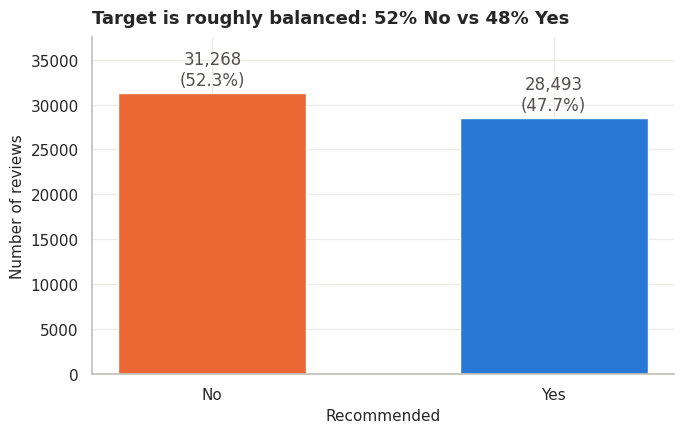

             reviews    pct
recommended                
No             31268 52.320
Yes            28493 47.680
Majority / minority ratio: 1.10


In [ ]:
# Chart - 15 visualization code
target_counts = eda_df['recommended'].map({1: 'Yes', 0: 'No'}).value_counts()
target_pct = target_counts / target_counts.sum() * 100
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(target_counts.index, target_counts.values, color=[TARGET_COLORS[i] for i in target_counts.index], width=0.55)
ax.bar_label(bars, labels=[f'{c:,}\n({p:.1f}%)' for c, p in zip(target_counts, target_pct)], padding=3, color=MUTED)
ax.set_ylim(0, target_counts.max() * 1.2)
finish(ax, 'Target is roughly balanced: 52% No vs 48% Yes', 'Recommended', 'Number of reviews')
plt.tight_layout(); plt.show()
imbalance_ratio = target_counts.max() / target_counts.min()
print(target_counts.to_frame('reviews').assign(pct=target_pct.round(2)))
print(f'Majority / minority ratio: {imbalance_ratio:.2f}')

##### 1. Why did you pick the specific chart?

A simple bar chart with counts and percentages is the clearest way to judge class balance.

##### 2. What is/are the insight(s) found from the chart?

- **No: 31,268 reviews (52.3%)**, **Yes: 28,493 reviews (47.7%)**. The majority/minority ratio is **1.10**.
- **The target is not imbalanced** - both classes are well represented.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** with balanced classes, accuracy is meaningful, and no resampling is needed. Because both errors matter to IndiGo (missing an unhappy passenger vs wrongly flagging a happy one), we still focus on **F1** and **ROC-AUC**.

**Negative:** slightly more than half of all reviewers would *not* recommend the airline they flew - a reminder that negative word-of-mouth is common in this industry.

### Do you think the dataset is imbalanced? Explain Why.
**No.** The minority class (Yes) is 47.7% of the data and the ratio is 1.10 : 1. A dataset is usually called imbalanced when the minority class is well below ~30-35%.

**Decision:**
- **No SMOTE / oversampling / undersampling** - creating synthetic reviews is unnecessary and could add noise.
- Use a **stratified** train-test split and **stratified** cross-validation so both sets keep the 52/48 ratio.
- In tuning, `class_weight='balanced'` is still tested for Logistic Regression as a check; with balanced data it is expected to make little difference.
- Evaluate with **precision, recall, F1, ROC-AUC and the confusion matrix**, not accuracy alone.

## **SECTION 7 — Missing Values & Data Cleaning**

**What:** measure missing values in every column, understand **why** they are missing, and decide how to handle each one.

**Why:** the right treatment depends on the reason. Values missing at random can be imputed; values missing for a systematic reason may carry information; a column that is mostly missing may be better dropped.

### 7.1 Missing Values/Null Values Count

In [ ]:
# Missing Values/Null Values Count (after removing blank rows and duplicates)
miss = missing_report(df.drop(columns=['review_date_dt', 'date_flown_dt']))
miss

,missing_count,missing_pct,dtype
aircraft,42695,69.780,object
ground_service,24014,39.250,float64
date_flown,23749,38.820,object
route,23670,38.690,object
traveller_type,23643,38.640,object
entertainment,20953,34.250,float64
food_bev,12842,20.990,float64
seat_comfort,4972,8.130,float64
cabin_service,4943,8.080,float64
cabin,2478,4.050,object


#### Chart - 16 - Missing values per column

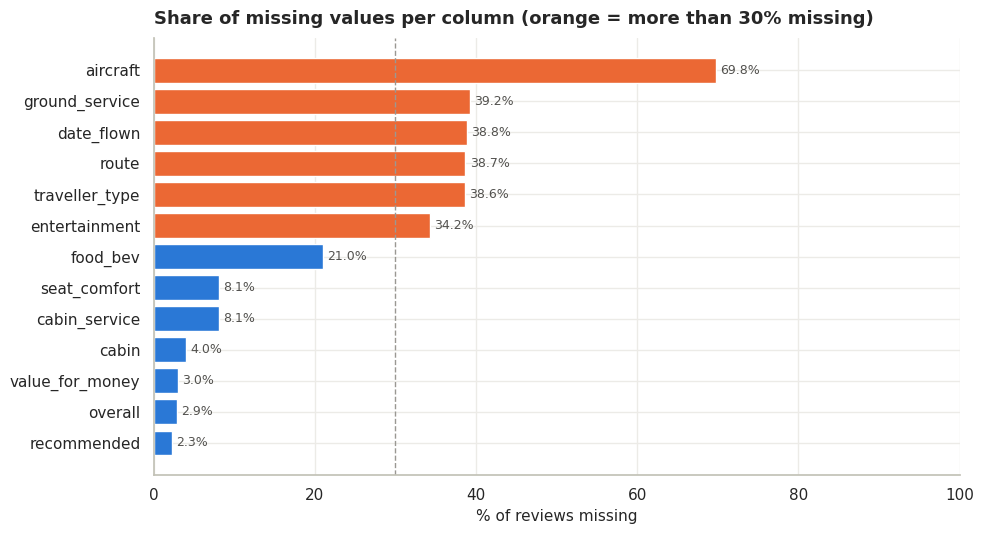

In [ ]:
# Visualizing the missing values
plot_miss = miss[miss['missing_pct'] > 0].sort_values('missing_pct')
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(plot_miss.index, plot_miss['missing_pct'], color=[HIGHLIGHT if v > 30 else PRIMARY for v in plot_miss['missing_pct']])
label_bars(ax, fmt='{:.1f}%')
ax.axvline(30, color=NEUTRAL, linestyle='--', linewidth=1)
ax.set_xlim(0, 100)
finish(ax, 'Share of missing values per column (orange = more than 30% missing)', '% of reviews missing', '')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A sorted horizontal bar chart makes it easy to see which columns have serious missing-value problems; the 30% line highlights the heavy cases.

##### 2. What is/are the insight(s) found from the chart?

- **aircraft (69.8%)**, **ground_service (39.2%)**, **date_flown, route and traveller_type (~39%)** and **entertainment (34.2%)** are heavily missing.
- **food_bev** (21.0%) is moderately missing; **seat_comfort / cabin_service** (8.1%), **cabin** (4.0%), **value_for_money** (3.0%), **overall** (2.9%) and **recommended** (2.3%) have little missing.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the core ratings (seat comfort, cabin service, value for money) are well populated, so the model has reliable inputs.

**Negative:** columns with more than a third missing cannot simply be dropped row-by-row (we would lose too many reviews). The next chart explains why they are missing.

#### Chart - 17 - Missing values by review year (heatmap)

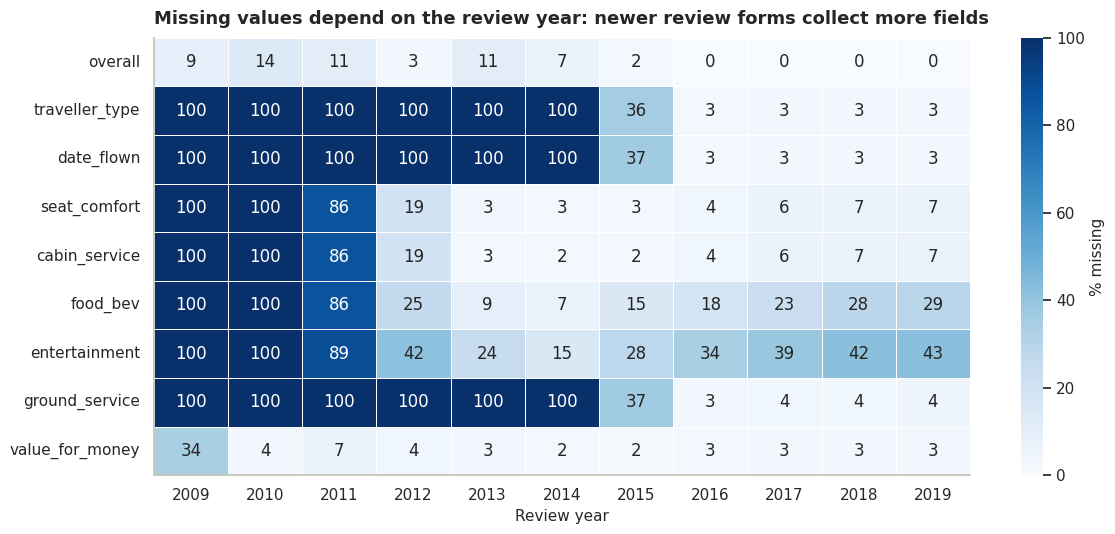

In [ ]:
# Question: is missingness random, or does it depend on when the review was written?
check_cols = ['overall', 'traveller_type', 'date_flown'] + RATING_COLS
miss_by_year = df.groupby(df['review_date_dt'].dt.year)[check_cols].apply(lambda d: d.isna().mean() * 100)
miss_by_year = miss_by_year.loc[2009:]                  # years with a meaningful number of reviews
fig, ax = plt.subplots(figsize=(12, 5.5))
sns.heatmap(miss_by_year.T, annot=True, fmt='.0f', cmap='Blues', vmin=0, vmax=100, linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% missing'}, ax=ax)
finish(ax, 'Missing values depend on the review year: newer review forms collect more fields', 'Review year', '')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A heatmap of "% missing" by year and column reveals patterns that a single overall percentage hides.

##### 2. What is/are the insight(s) found from the chart?

- Missingness is **systematic, not random**. `traveller_type`, `date_flown` and `ground_service` are **100% missing before 2015** and almost complete afterwards - these fields were added to the review form later.
- `seat_comfort` and `cabin_service` become available from **2012**.
- `entertainment` and `food_bev` stay partly missing in all years - likely flights where there was no entertainment or no meal to rate.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** knowing the cause lets us choose a sensible treatment instead of blindly dropping rows.

**Negative:** because availability depends on the year, a missing value partly tells the model *when* the review was written. We therefore add `review_year` as a feature and treat "not rated" explicitly.

### 7.2 Is missingness related to the target?

In [ ]:
# Recommendation rate when a value is present vs missing
miss_target = pd.DataFrame({
    col: {'rec_rate_if_present': eda_df.loc[eda_df[col].notna(), 'recommended'].mean(),
          'rec_rate_if_missing': eda_df.loc[eda_df[col].isna(), 'recommended'].mean(),
          'n_missing': eda_df[col].isna().sum()}
    for col in ['overall', 'traveller_type', 'cabin'] + RATING_COLS}).T
miss_target['difference'] = miss_target['rec_rate_if_missing'] - miss_target['rec_rate_if_present']
miss_target.round(3)

,rec_rate_if_present,rec_rate_if_missing,n_missing,difference
overall,0.491,0.003,"1,764.000",-0.488
traveller_type,0.427,0.561,"22,222.000",0.134
cabin,0.481,0.270,"1,057.000",-0.211
seat_comfort,0.481,0.402,"3,550.000",-0.079
cabin_service,0.481,0.405,"3,521.000",-0.077
food_bev,0.519,0.297,"11,420.000",-0.222
entertainment,0.509,0.411,"19,531.000",-0.098
ground_service,0.429,0.556,"22,592.000",0.127
value_for_money,0.480,0.071,434.000,-0.408


**Interpretation:** missingness carries information. Only **7.1%** of reviews with a missing value-for-money rating recommend (vs 48.0% when it is present), and **almost nobody** with a missing overall rating recommends (0.3%). A missing food & beverage rating also goes with lower recommendation (29.7% vs 51.9%). So "not rated" should not be hidden by plain imputation - we keep a **missing-value indicator**.

### 7.3 Handling Missing Values & Missing Value Imputation

| Column(s) | % missing | Decision | Why |
|---|---|---|---|
| `recommended` (target) | 2.3% | **Drop rows** | A review without a label cannot be used to train or test a classifier; imputing the target would invent answers |
| Six service ratings | 3.0%-39.2% | **Median imputation + missing indicator**, inside the pipeline, fitted on training data only | Median suits ordinal 1-5 ratings and is robust; the indicator keeps the "not rated" signal (Section 7.2); fitting on training data only prevents leakage |
| `overall` | 2.9% | Same as above (used only in the benchmark models) | Consistency with other ratings |
| `traveller_type`, `cabin` | 38.6%, 4.0% | Fill with the category **"Unknown"** | Missing is a meaningful group (mostly pre-2015 reviews); a constant fill uses no information from the test set |
| `aircraft` | 69.8% | **Not used in the model** | Mostly missing and 2,088 inconsistent spellings |
| `date_flown`, `route` | ~39% | Not used in the model | Mostly missing; route is free text with ~24,500 unique values |
| `author`, `customer_review` | 0% | Not used in the model | Author is an identifier; review text is out of scope (NLP) and directly states the verdict |

In [ ]:
# Handling Missing Values & Missing Value Imputation (steps that do not need to "learn" from data)
model_df = df.dropna(subset=['recommended']).copy()               # 1. drop reviews without a target
model_df['recommended'] = model_df['recommended'].astype(int)
for col in ['traveller_type', 'cabin']:                             # 2. constant fill for categorical columns
    model_df[col] = model_df[col].fillna('Unknown')
# 3. Median imputation + missing indicators for ratings happen INSIDE the pipeline (Section 12),
#    after the train-test split, so the medians are learned from training data only.
print(f'Rows for modelling: {len(model_df):,} (dropped {len(df) - len(model_df):,} reviews without a target)')
print(model_df[['traveller_type', 'cabin']].isna().sum().to_dict())

Rows for modelling: 59,761 (dropped 1,422 reviews without a target)
{'traveller_type': 0, 'cabin': 0}


#### What all missing value imputation techniques have you used and why did you use those techniques?
1. **Listwise deletion for the target only** (1,422 rows, 2.3%) - a label cannot be imputed honestly.
2. **Constant "Unknown" category** for `traveller_type` and `cabin` - keeps the rows and treats "not stated" as its own group.
3. **Median imputation with a missing-indicator flag** for the numeric ratings - the median is robust for bounded ordinal scores, and the indicator lets the model learn that "not rated" is informative. This is done inside a scikit-learn `Pipeline` after the train-test split to prevent data leakage.

## **SECTION 8 — Outlier Analysis**

**What:** check the numeric variables for outliers using box plots and the IQR rule. **Why:** outliers can distort models - but deleting genuine observations removes real customer opinions, so we first check whether they are valid.

#### Chart - 18 - Box plots of the numeric ratings

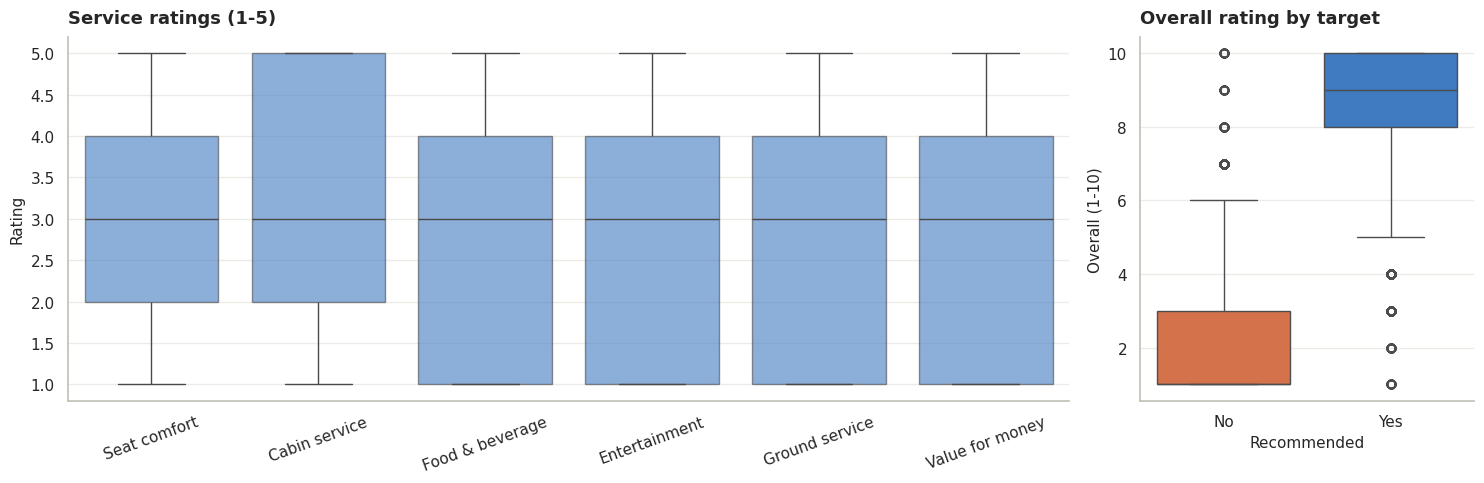

                  min    max  IQR outliers
seat_comfort    1.000  5.000             0
cabin_service   1.000  5.000             0
food_bev        1.000  5.000             0
entertainment   1.000  5.000             0
ground_service  1.000  5.000             0
value_for_money 1.000  5.000             0
overall         1.000 10.000             0

Review years: 2002-2019 | reviews before 2010: 203 (0.34%)


In [ ]:
# Handling Outliers & Outlier treatments - visual check
fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [3, 1]})
sns.boxplot(data=model_df[RATING_COLS].rename(columns=RATING_LABELS), color=PRIMARY, ax=axes[0], boxprops=dict(alpha=0.6))
axes[0].tick_params(axis='x', rotation=20)
finish(axes[0], 'Service ratings (1-5)', '', 'Rating')
sns.boxplot(data=model_df, x='recommended', y='overall', hue='recommended', palette=[NO_COLOR, YES_COLOR], legend=False, ax=axes[1])
axes[1].set_xticklabels(['No', 'Yes'])
finish(axes[1], 'Overall rating by target', 'Recommended', 'Overall (1-10)')
plt.tight_layout(); plt.show()

def iqr_outliers(series):
    """Number of values outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]."""
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)).sum()

numeric_check = RATING_COLS + ['overall']
outlier_table = pd.DataFrame({'min': model_df[numeric_check].min(), 'max': model_df[numeric_check].max(),
                              'IQR outliers': [iqr_outliers(model_df[c].dropna()) for c in numeric_check]})
print(outlier_table)
yr = model_df['review_date_dt'].dt.year
print(f'\nReview years: {yr.min()}-{yr.max()} | reviews before 2010: {(yr < 2010).sum()} ({(yr < 2010).mean():.2%})')

##### 1. Why did you pick the specific chart?

Box plots show the median, spread and any points beyond the whiskers (potential outliers). The IQR table confirms the visual check with numbers.

##### 2. What is/are the insight(s) found from the chart?

- All ratings stay inside their valid ranges (1-5 for services, 1-10 for overall); there are **no impossible values**.
- The IQR rule flags **no outliers** in any rating: the scales are bounded and the spread is wide because opinions are polarised.
- Recommenders' overall ratings are concentrated at 8-10 and non-recommenders' at 1-3, with a few genuine exceptions (e.g., an overall of 1 with "yes").
- The only "unusual" values are the **203 reviews from 2002-2009** (0.34% of the data) - these are real, older reviews.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** no data needs to be deleted or capped, so every genuine passenger opinion is kept.

**Negative:** the rare contradictions (high overall score but "no", or the reverse) are genuine noise in human answers; they limit how close to 100% any model can get.

##### What all outlier treatment techniques have you used and why did you use those techniques?
**No treatment was applied, on purpose.** The ratings are bounded scales, all values are valid, and the IQR rule finds no outliers. Extreme scores (1 or 5) are real customer opinions and are exactly the information the model needs. Old reviews (2002-2009) are genuine and kept; `review_year` lets the model account for era. Tree-based models are also insensitive to outliers by design.

## **SECTION 9 — Feature Engineering**

**What:** create new features only where there is a clear business or statistical reason. **Why:** extra features add complexity; each one must earn its place.

| Engineered feature | Business logic | Used in model? |
|---|---|---|
| `review_year` (from `review_date`) | Customer expectations and the review form changed over time; the recommendation rate fell from about 53% (2016) to 31% (2019). The year controls for this era effect. | **Yes** |
| Missing-value indicators for each rating (created by the imputer) | "Not rated" carries information (Section 7.2) | **Yes** (inside the pipeline) |
| `service_score` = average of the available service ratings | A single "overall service experience" number, useful for management dashboards and segment analysis | **No** - it is an exact combination of the six ratings, so it would add redundancy (checked with VIF in Section 10) |

**Features considered and rejected:**
- *Month of review / month flown* - no business reason to expect a seasonal effect on willingness to recommend; `date_flown` is 39% missing.
- *Review lag (review date minus flight date)* - only available for ~61% of reviews and not a service lever.
- *Text features from `customer_review`* - would require NLP, and the text often states the verdict directly (leakage).

In [ ]:
# Manipulate Features to minimize feature correlation and create new features
model_df['review_year'] = model_df['review_date_dt'].dt.year
model_df['service_score'] = model_df[RATING_COLS].mean(axis=1)        # mean of the ratings that were given
print(model_df[['review_year', 'service_score']].describe().round(2))
print('Reviews with no service rating at all (service_score missing):', model_df['service_score'].isna().sum())

       review_year  service_score
count   59,761.000     59,470.000
mean     2,015.590          2.920
std          2.130          1.350
min      2,002.000          1.000
25%      2,014.000          1.600
50%      2,016.000          3.000
75%      2,017.000          4.170
max      2,019.000          5.000
Reviews with no service rating at all (service_score missing): 291


#### Chart - 19 - Recommendation rate by overall service score band

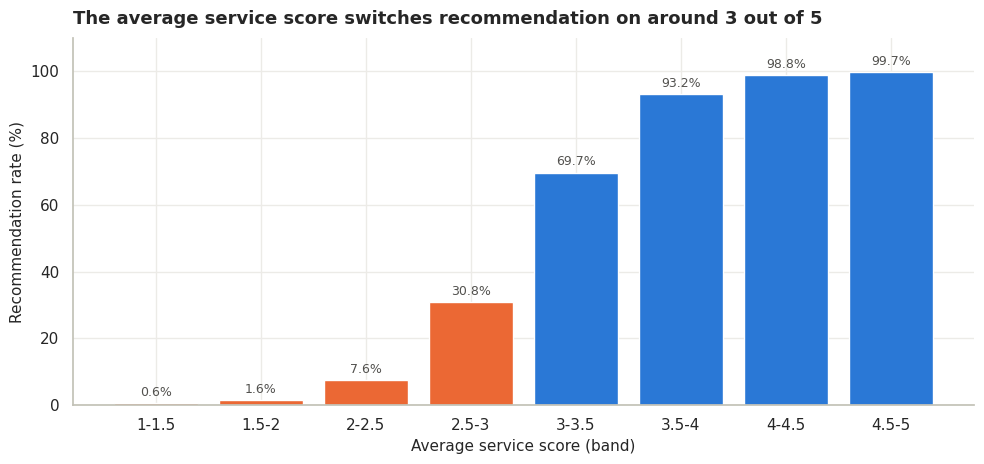

               mean   size
service_score             
1-1.5         0.006  13931
1.5-2         0.016   7069
2-2.5         0.076   5041
2.5-3         0.308   5147
3-3.5         0.697   4276
3.5-4         0.932   8259
4-4.5         0.988   7367
4.5-5         0.997   8380


In [ ]:
# Question: does the combined service score separate recommenders from non-recommenders?
bands = pd.cut(model_df['service_score'], bins=[0.99, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5],
               labels=['1-1.5', '1.5-2', '2-2.5', '2.5-3', '3-3.5', '3.5-4', '4-4.5', '4.5-5'])
band_rate = model_df.groupby(bands, observed=True)['recommended'].agg(['mean', 'size'])
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(band_rate.index.astype(str), band_rate['mean'] * 100, color=[YES_COLOR if v >= 0.5 else NO_COLOR for v in band_rate['mean']])
label_bars(ax, fmt='{:.1f}%')
ax.set_ylim(0, 110)
finish(ax, 'The average service score switches recommendation on around 3 out of 5', 'Average service score (band)', 'Recommendation rate (%)')
plt.tight_layout(); plt.show()
print(band_rate.round(3))

##### 1. Why did you pick the specific chart?

A bar chart over score bands shows how the combined service score maps to the recommendation rate and where the tipping point is.

##### 2. What is/are the insight(s) found from the chart?

- Below an average service score of 2, fewer than 2% recommend; above 4, about 99% do.
- The tipping point is between **2.5 and 3.5** (30.8% recommend in the 2.5-3 band vs 69.7% in the 3-3.5 band) - the "zone of indifference" where small service improvements change the outcome the most.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the average service score is a simple, explainable KPI for management: keeping it above ~3.5 is associated with strong advocacy.

**Negative:** because this score is a combination of the six ratings, it is **not added to the model** (it would duplicate information already there).

### Categorical Encoding - What techniques have you used & why?
- `traveller_type` (5 values incl. "Unknown") and `cabin` (5 values incl. "Unknown") are **nominal** (no natural order) and have few levels, so **One-Hot Encoding** is used. `handle_unknown='ignore'` makes the pipeline robust to unseen categories in new data.
- `airline` is **not** encoded as a feature (explained in Section 10).
- The target `recommended` was mapped to **1 (yes) / 0 (no)**.

### Textual Data Preprocessing
Not applicable - `customer_review` is not used (no NLP in this project's scope).

### Data Transformation - is it needed?
**No.** Ratings are bounded and not skewed by extreme values; tree models do not need transformation, and Logistic Regression only needs scaling (Section 12).

### Dimensionality Reduction - is it needed?
**No.** After encoding there are fewer than 25 input columns for ~48,000 training rows, and PCA would make the business interpretation of each service area impossible.

## **SECTION 10 — Correlation & Multicollinearity**

**What:** measure correlations between the numeric variables and with the target, and calculate the Variance Inflation Factor (VIF). **Why:** highly correlated predictors make Logistic Regression coefficients unstable and hard to interpret, and a predictor that is almost the same as the target creates leakage.

#### Chart - 20 - Correlation Heatmap

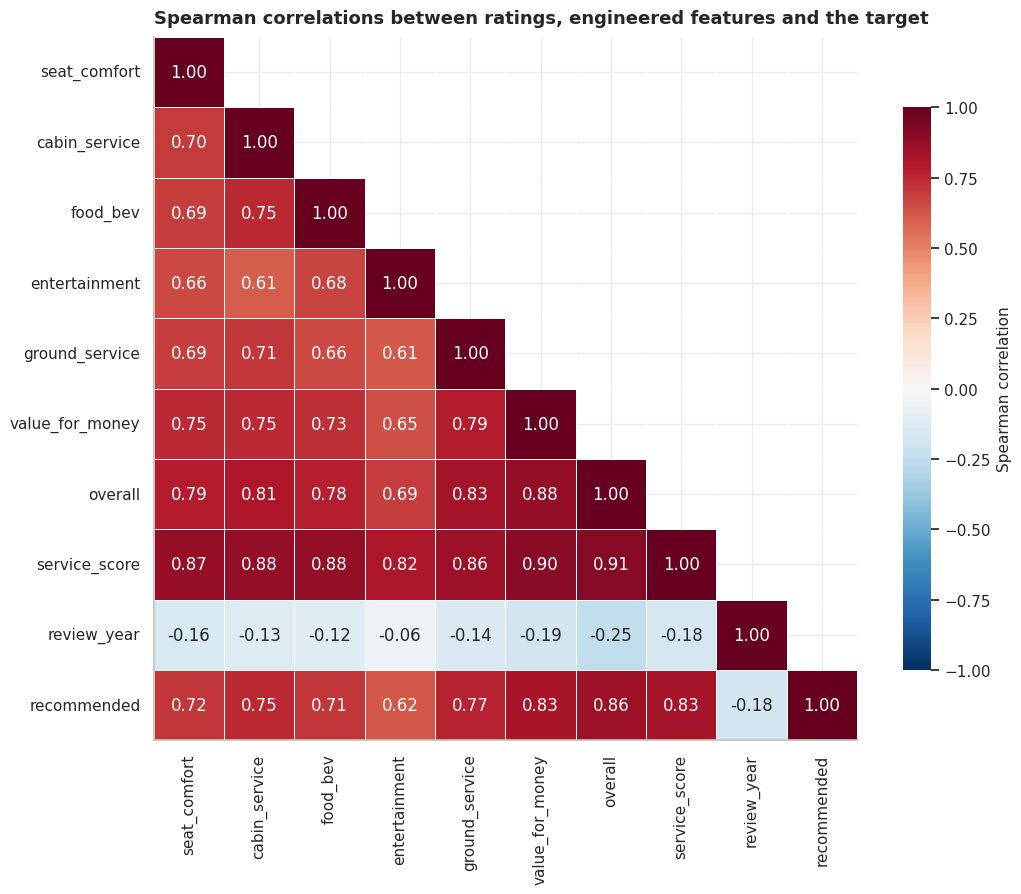

Correlation with the target (sorted):
overall            0.858
service_score      0.831
value_for_money    0.827
ground_service     0.772
cabin_service      0.753
seat_comfort       0.716
food_bev           0.714
entertainment      0.619
review_year       -0.180
Name: recommended, dtype: float64


In [ ]:
# Correlation Heatmap visualization code (Spearman - suitable for ordinal ratings)
corr_cols = RATING_COLS + ['overall', 'service_score', 'review_year', 'recommended']
corr = model_df[corr_cols].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Spearman correlation', 'shrink': 0.8}, ax=ax)
finish(ax, 'Spearman correlations between ratings, engineered features and the target')
plt.tight_layout(); plt.show()
print('Correlation with the target (sorted):')
print(corr['recommended'].drop('recommended').sort_values(ascending=False).round(3))

##### 1. Why did you pick the specific chart?

A correlation heatmap summarises every pairwise relationship (including with the target) in one view. Spearman correlation is used because the ratings are ordinal.

##### 2. What is/are the insight(s) found from the chart?

- **Correlation with the target:** `overall` (0.86), `service_score` (0.83), `value_for_money` (0.83), `ground_service` (0.77), `cabin_service` (0.75), `seat_comfort` (0.72), `food_bev` (0.71), `entertainment` (0.62). `review_year` is weakly negative (-0.18).
- **Between predictors:** the service ratings are moderately to strongly correlated with each other (0.61-0.79) - a good trip tends to be rated well everywhere.
- `overall` and `service_score` are very strongly correlated with the individual ratings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** every service rating is strongly related to recommendation, so all six are worth keeping as candidate features.

**Negative / risk:** the strong correlations between ratings mean the model cannot fully separate their individual effects - feature importance should be read as "predictive importance", not as precise causal effects.

### 10.1 Variance Inflation Factor (VIF)

In [ ]:
# VIF on complete cases (rows where all ratings are present), for three candidate feature sets
complete = model_df.dropna(subset=RATING_COLS + ['overall'])
print(f'Complete cases used for VIF: {len(complete):,}')
vif_tables = {
    'A: six service ratings': compute_vif(complete[RATING_COLS]),
    'B: six ratings + overall': compute_vif(complete[RATING_COLS + ['overall']]),
    'C: six ratings + service_score': compute_vif(complete[RATING_COLS + ['service_score']]),
}
vif_df = pd.concat(vif_tables, axis=1).round(2)
vif_df

Complete cases used for VIF: 22,850


,A: six service ratings,B: six ratings + overall,C: six ratings + service_score
value_for_money,3.950,5.500,inf
food_bev,3.450,3.570,inf
cabin_service,3.140,3.300,inf
seat_comfort,3.090,3.190,inf
ground_service,2.720,3.190,inf
entertainment,2.450,2.470,inf
overall,NaN,8.920,NaN
service_score,NaN,NaN,inf


**Interpretation (rule of thumb: VIF above 5 = concerning, above 10 = severe):**
- **Set A - six service ratings only:** all VIFs are below 5 (highest: value for money 3.95), so the ratings are correlated but **not severely collinear**. They can be used together.
- **Set B - adding `overall`:** `overall` has a VIF of **8.92** and pushes value for money above 5 (5.50) - it is largely explained by the six ratings, and it is also almost a proxy for the target (Chart 3).
- **Set C - adding `service_score`:** VIFs become **infinite** because `service_score` is an exact average of the other columns (perfect multicollinearity). This confirms it should **not** go into the model.

### 10.2 Feature selection - final decision

| Variable | Decision | Reason |
|---|---|---|
| Six service ratings | **Keep** | Strong relationship with the target; VIF < 5; directly actionable for IndiGo |
| `traveller_type`, `cabin` | **Keep** | Significant (chi-square tests), describe customer segments |
| `review_year` | **Keep** | Controls for the era effect in ratings and missingness |
| `overall` | **Exclude from the main model; use as a benchmark** | Given at the same moment as the recommendation and almost a restatement of it (Spearman 0.86; 94%+ recommend at 7 or above). Including it would hide which service areas matter, and it is not a lever IndiGo can directly manage. Section 15 shows what happens if it is included. |
| `service_score` | Exclude | Perfect multicollinearity with the six ratings |
| `airline` | Exclude | 81 airlines; the goal is a model of *what drives recommendation* that applies to IndiGo, not one that memorises competitor brands. Airline differences are largely explained by the service ratings (Chart 12) |
| `aircraft`, `route`, `date_flown`, `author`, `customer_review` | Exclude | Missing / free text / identifier / out of scope (Section 7) |

##### What all feature selection methods have you used and why?
A combination of **domain logic** (actionability, leakage risk), **filter methods** (correlation with the target, chi-square tests) and **multicollinearity checks** (VIF). Embedded importance from the models is reviewed in Section 18.

##### Which all features you found important and why?
From EDA: value for money, ground service and cabin service show the strongest association with recommendation; entertainment the weakest. The model-based ranking is in Section 18.

#### Chart - 21 - Pair Plot

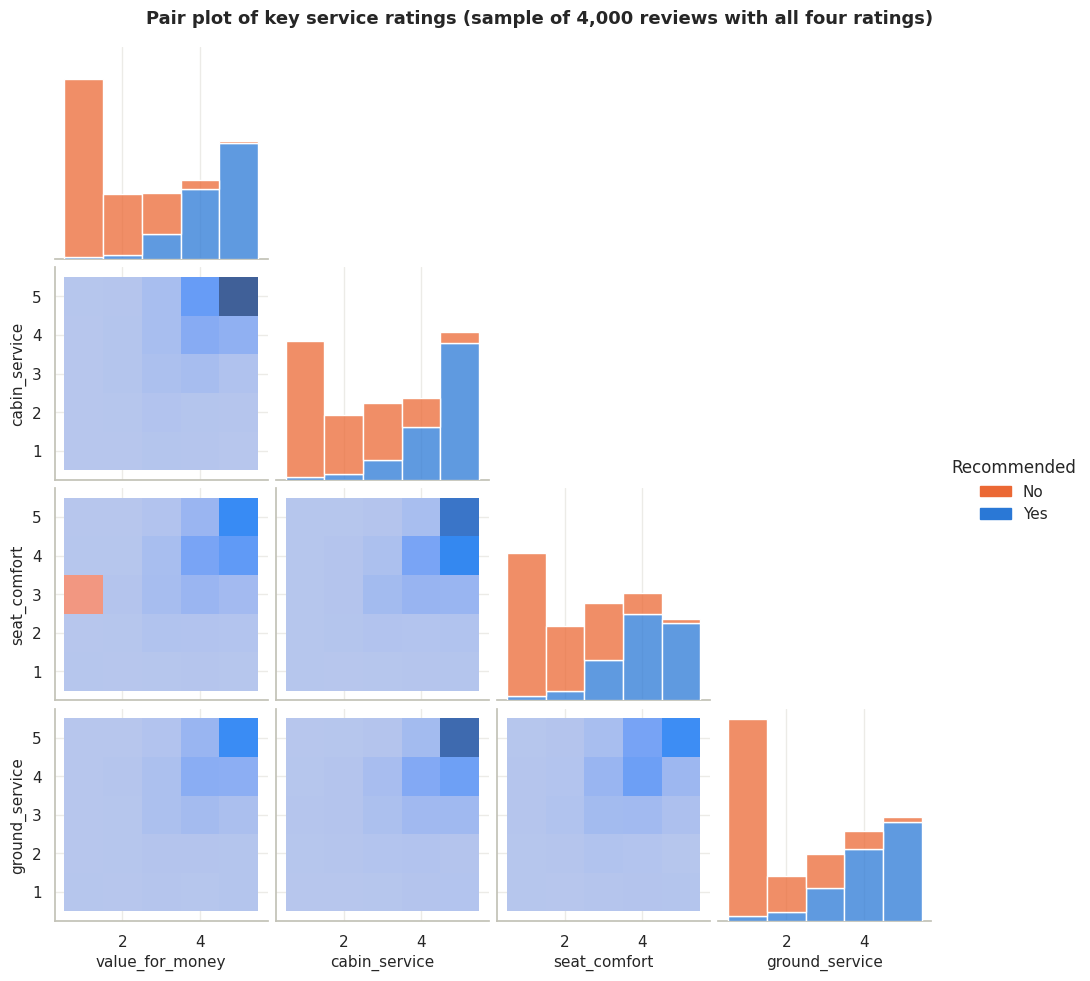

In [ ]:
# Pair Plot visualization code - random sample, 2-D histograms because ratings are discrete
pair_sample = model_df.dropna(subset=['value_for_money', 'cabin_service', 'seat_comfort', 'ground_service']).sample(4000, random_state=RANDOM_STATE)
pair_sample = pair_sample.assign(Recommended=pair_sample['recommended'].map({1: 'Yes', 0: 'No'}))
g = sns.pairplot(pair_sample[['value_for_money', 'cabin_service', 'seat_comfort', 'ground_service', 'Recommended']],
                 hue='Recommended', palette=TARGET_COLORS, kind='hist', diag_kind='hist', corner=True, height=2.4,
                 diag_kws=dict(multiple='stack', discrete=True), plot_kws=dict(discrete=True))
g.fig.suptitle('Pair plot of key service ratings (sample of 4,000 reviews with all four ratings)', y=1.02, fontsize=13, fontweight='bold')
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot shows every pairwise relationship between the main ratings, coloured by the target. 2-D histograms are used instead of scatter points because ratings take only five values (scatter points would overlap completely).

##### 2. What is/are the insight(s) found from the chart?

- Recommenders (blue) cluster in the top-right of every panel (high on both ratings); non-recommenders (orange) cluster bottom-left.
- The diagonal histograms show almost no overlap at the extremes (1 and 5) and most of the overlap at 3 - the "zone of indifference".
- The ratings move together, confirming the positive correlations in the heatmap.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the clear separation suggests the classification task is learnable with high accuracy.

**Negative:** passengers who give middle scores (3) are the hardest to classify - and also the ones IndiGo can most easily move toward advocacy.

## **SECTION 11 — Train-Test Split**

**What:** separate the features (X) from the target (y) and split into 80% training and 20% testing data.

**Why:** the test set simulates new, unseen passengers. The split is done **before** any imputation, scaling or encoding is fitted, so no information from the test set leaks into training. `stratify=y` keeps the same 52/48 class ratio in both sets.

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.
TARGET = 'recommended'
NUM_FEATURES = RATING_COLS + ['review_year']          # numeric inputs for the main model
CAT_FEATURES = ['traveller_type', 'cabin']            # categorical inputs
FEATURES = NUM_FEATURES + CAT_FEATURES

X = model_df[FEATURES + ['overall', 'airline']]      # 'overall' kept only for the benchmark; 'airline' for IndiGo analysis
y = model_df[TARGET]

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_train, X_test = X_train_full[FEATURES], X_test_full[FEATURES]     # main feature set

print(f'Training set: {X_train.shape[0]:,} rows | Test set: {X_test.shape[0]:,} rows | Features: {len(FEATURES)}')
print('Class ratio (share of Yes) - train: {:.3f} | test: {:.3f}'.format(y_train.mean(), y_test.mean()))

Training set: 47,808 rows | Test set: 11,953 rows | Features: 9
Class ratio (share of Yes) - train: 0.477 | test: 0.477


##### What data splitting ratio have you used and why?
**80:20.** With ~59,800 reviews, 20% gives a large test set (~12,000 reviews) for reliable metrics, while 80% (~47,800 reviews) is more than enough to train. Model selection and tuning use **5-fold stratified cross-validation on the training set only**, so the test set is touched only for final evaluation.

## **SECTION 12 — Preprocessing Pipeline**

**What:** build a reusable scikit-learn `Pipeline` + `ColumnTransformer` that (1) imputes missing ratings with the median and adds missing indicators, (2) optionally scales numeric features, and (3) one-hot encodes the categorical features.

**Why:** a pipeline guarantees that every transformation is **learned on the training data only** and applied identically to the test data - including inside cross-validation folds. This is the standard way to prevent data leakage.

**Is scaling needed?**
| Model | Scaling? | Reason |
|---|---|---|
| Logistic Regression | **Yes (StandardScaler)** | Uses a weighted sum of features and L2 regularisation; unscaled features would be penalised unequally, and standardised coefficients become comparable for interpretation |
| Random Forest / Gradient Boosting | **No** | Trees split on thresholds of one feature at a time, so the scale of a feature does not change the splits |

In [ ]:
# Scaling your data - reusable preprocessing builder
def build_preprocessor(num_features, cat_features, scale):
    """Median imputation + missing indicators (+ optional scaling) for numeric columns;
    one-hot encoding for categorical columns."""
    num_steps = [('impute', SimpleImputer(strategy='median', add_indicator=True))]
    if scale:
        num_steps.append(('scale', StandardScaler()))
    return ColumnTransformer([
        ('num', Pipeline(num_steps), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ])

# Show what the transformed training data looks like
demo = build_preprocessor(NUM_FEATURES, CAT_FEATURES, scale=True).fit(X_train)
feature_names = [n.replace('num__', '').replace('cat__', '') for n in demo.get_feature_names_out()]
print(f'{len(feature_names)} model inputs after preprocessing:')
print(feature_names)

23 model inputs after preprocessing:
['seat_comfort', 'cabin_service', 'food_bev', 'entertainment', 'ground_service', 'value_for_money', 'review_year', 'missingindicator_seat_comfort', 'missingindicator_cabin_service', 'missingindicator_food_bev', 'missingindicator_entertainment', 'missingindicator_ground_service', 'missingindicator_value_for_money', 'traveller_type_Business', 'traveller_type_Couple Leisure', 'traveller_type_Family Leisure', 'traveller_type_Solo Leisure', 'traveller_type_Unknown', 'cabin_Business Class', 'cabin_Economy Class', 'cabin_First Class', 'cabin_Premium Economy', 'cabin_Unknown']


##### Which method have you used to scale you data and why?
**StandardScaler** (mean 0, standard deviation 1) for Logistic Regression only - it is the standard choice for regularised linear models and makes coefficients comparable ("effect of a one-standard-deviation increase"). No scaling for tree models.

### Handling Imbalanced Dataset
As shown in Section 6, the classes are balanced (52.3% / 47.7%), so **no resampling is applied**. Stratified splitting and cross-validation keep the ratio stable, and `class_weight='balanced'` is tested during tuning as a check.

### Model evaluation helpers

**What:** one function evaluates any fitted model in the same way. **Why:** identical evaluation for every model makes the comparison fair and avoids repeated code.

**Metrics in the context of airline recommendations** (positive class = "Yes, would recommend"):

| Metric | Plain-English meaning for IndiGo |
|---|---|
| **Accuracy** | Share of all passengers classified correctly |
| **Precision** | Of the passengers the model says *will* recommend, how many actually do. High precision = promoter lists for referral campaigns are not wasted on unhappy passengers |
| **Recall** | Of the passengers who *actually* recommend, how many the model finds. High recall = few promoters are missed |
| **F1-score** | Balance of precision and recall (main selection metric) |
| **ROC-AUC** | How well the model ranks passengers from "most likely" to "least likely" to recommend, across all thresholds (1.0 = perfect, 0.5 = random) |
| **Confusion matrix** | Counts of correct and wrong predictions; the **false positives** (predicted promoter but actually a detractor) are the costliest error, because unhappy passengers would be missed for service recovery |

In [ ]:
RESULTS = {}            # stores the test-set metrics of every model for the comparison table

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, show=True):
    """Fit-free evaluation of an already fitted model: metrics, classification report,
    confusion matrix, ROC curve and a metric score chart."""
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    metrics = {'Accuracy': accuracy_score(y_te, y_pred), 'Precision': precision_score(y_te, y_pred),
               'Recall': recall_score(y_te, y_pred), 'F1': f1_score(y_te, y_pred),
               'ROC-AUC': roc_auc_score(y_te, y_prob),
               'Train F1': f1_score(y_tr, model.predict(X_tr))}      # to check over-fitting
    RESULTS[name] = metrics
    if show:
        print(f'===== {name} =====')
        print(classification_report(y_te, y_pred, target_names=['No (0)', 'Yes (1)'], digits=3))
        fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
        ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred), display_labels=['No', 'Yes']).plot(
            ax=axes[0], cmap='Blues', colorbar=False, values_format=',')
        finish(axes[0], 'Confusion matrix (test set)', 'Predicted', 'Actual')
        axes[0].grid(False)
        fpr, tpr, _ = roc_curve(y_te, y_prob)
        axes[1].plot(fpr, tpr, color=PRIMARY, linewidth=2, label=f'AUC = {metrics["ROC-AUC"]:.3f}')
        axes[1].plot([0, 1], [0, 1], color=NEUTRAL, linestyle='--', label='Random guess')
        axes[1].legend(frameon=False, loc='lower right')
        finish(axes[1], 'ROC curve (test set)', 'False positive rate', 'True positive rate', legend=True)
        score_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
        axes[2].bar(score_names, [metrics[m] for m in score_names], color=PRIMARY)
        label_bars(axes[2], fmt='{:.3f}')
        axes[2].set_ylim(0, 1.1)
        finish(axes[2], 'Evaluation metric score chart', '', 'Score')
        plt.suptitle(name, fontsize=14, fontweight='bold', x=0.01, ha='left')
        plt.tight_layout(); plt.show()
    return metrics


def compare_models(names=None):
    """Comparison table of stored results, sorted by F1."""
    table = pd.DataFrame(RESULTS).T
    if names is not None:
        table = table.loc[names]
    return table.sort_values('F1', ascending=False).round(4)


def cv_score(model, X_tr, y_tr, scoring='f1'):
    """5-fold stratified cross-validation score on the training set (mean and std)."""
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring=scoring, n_jobs=-1)
    print(f'5-fold CV {scoring}: {scores.mean():.4f} (+/- {scores.std():.4f})')
    return scores
print('Evaluation helpers ready.')

Evaluation helpers ready.


## **SECTION 13 — Model 1: Logistic Regression**

**What:** a Logistic Regression classifier on the scaled, imputed and encoded features.

**Why this model first:** it is the standard, **interpretable baseline** for binary classification. Each coefficient shows the direction and strength of a feature's effect on the odds of recommending, which is easy to explain to management. If a simple model already performs well, a complex model must clearly beat it to be worth using.

5-fold CV f1: 0.9359 (+/- 0.0012)
===== Logistic Regression (baseline) =====
              precision    recall  f1-score   support

      No (0)      0.947     0.944     0.945      6254
     Yes (1)      0.938     0.942     0.940      5699

    accuracy                          0.943     11953
   macro avg      0.942     0.943     0.942     11953
weighted avg      0.943     0.943     0.943     11953



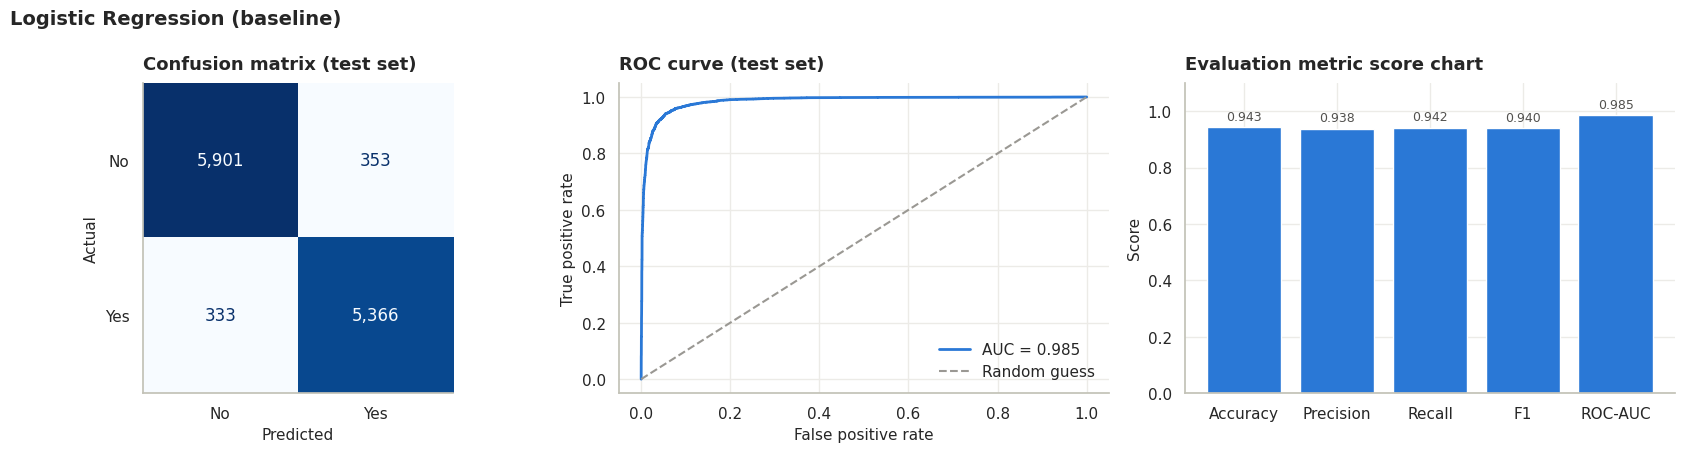

In [ ]:
# ML Model - 1 Implementation
log_reg = Pipeline([
    ('prep', build_preprocessor(NUM_FEATURES, CAT_FEATURES, scale=True)),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
# Fit the Algorithm
log_reg.fit(X_train, y_train)
# Predict on the model (predictions + probabilities are generated inside evaluate_model)
lr_cv = cv_score(log_reg, X_train, y_train)
evaluate_model('Logistic Regression (baseline)', log_reg, X_train, y_train, X_test, y_test);

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.


**How it works:** Logistic Regression estimates the probability of "Yes" with an S-shaped (logistic) function applied to a weighted sum of the features. Each weight (coefficient) shows how strongly a feature pushes the odds of recommending up or down.

**Performance (test set):** accuracy **0.943**, precision **0.938**, recall **0.942**, F1 **0.940**, ROC-AUC **0.985**. The confusion matrix shows **5,901** detractors and **5,366** promoters classified correctly, with **353** detractors wrongly predicted as promoters and **333** promoters missed.

**Stability and over-fitting:** 5-fold CV F1 on the training data is **0.936 (+/- 0.001)**, and training F1 (0.936) is almost the same as test F1 (0.940) - the model **generalises well and is not over-fitting**.

**Business meaning:** even a simple, transparent model predicts recommendation correctly for about 94 of every 100 passengers from their service ratings alone.


## **SECTION 14 — Model 2: Tree-based models (Random Forest and Gradient Boosting)**

**What:** two tree-based ensemble models.
- **Random Forest:** builds many decision trees on random samples of rows and features, then takes a majority vote.
- **Histogram Gradient Boosting:** builds trees one after another, each correcting the errors of the previous ones (scikit-learn's fast gradient-boosting implementation).

**Why:** tree ensembles can capture **non-linear effects and interactions** (e.g., "a low seat-comfort score matters only when value for money is also low") that Logistic Regression cannot, and they provide feature importance. Comparing them with the baseline tells us whether that extra complexity is worth it.

### 14.1 Random Forest

5-fold CV f1: 0.9301 (+/- 0.0015)
===== Random Forest (baseline) =====
              precision    recall  f1-score   support

      No (0)      0.938     0.940     0.939      6254
     Yes (1)      0.934     0.932     0.933      5699

    accuracy                          0.936     11953
   macro avg      0.936     0.936     0.936     11953
weighted avg      0.936     0.936     0.936     11953



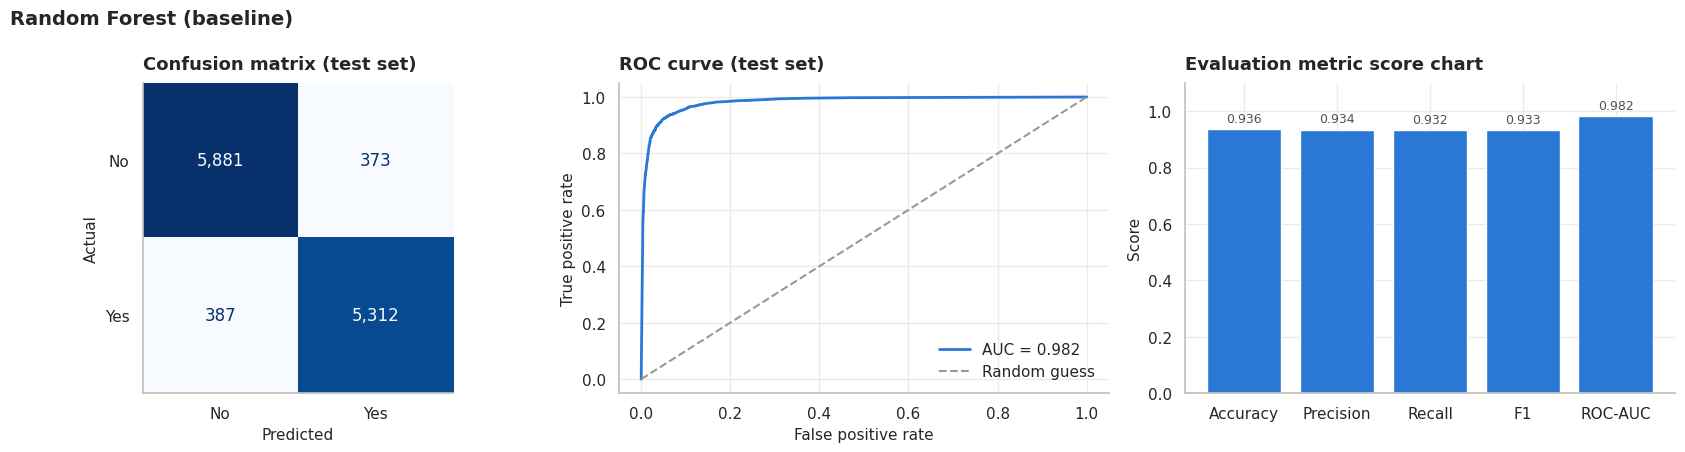

In [ ]:
# ML Model - 2 Implementation (Random Forest)
rf = Pipeline([
    ('prep', build_preprocessor(NUM_FEATURES, CAT_FEATURES, scale=False)),
    ('model', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
])
rf.fit(X_train, y_train)
rf_cv = cv_score(rf, X_train, y_train)
evaluate_model('Random Forest (baseline)', rf, X_train, y_train, X_test, y_test);

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.


**Performance (test set):** accuracy **0.936**, precision **0.934**, recall **0.932**, F1 **0.933**, ROC-AUC **0.982** (CV F1 0.930).

**Over-fitting check:** training F1 is **0.985** vs test F1 **0.933** - a gap of about **0.05**. With default settings the trees grow very deep and memorise the training data, so the Random Forest is **slightly worse than Logistic Regression** on unseen passengers.

**Confusion matrix:** 373 detractors wrongly predicted as promoters and 387 promoters missed - both higher than Logistic Regression.


### 14.2 Gradient Boosting (HistGradientBoostingClassifier)

5-fold CV f1: 0.9364 (+/- 0.0018)
===== Gradient Boosting (baseline) =====
              precision    recall  f1-score   support

      No (0)      0.946     0.946     0.946      6254
     Yes (1)      0.941     0.940     0.941      5699

    accuracy                          0.943     11953
   macro avg      0.943     0.943     0.943     11953
weighted avg      0.943     0.943     0.943     11953



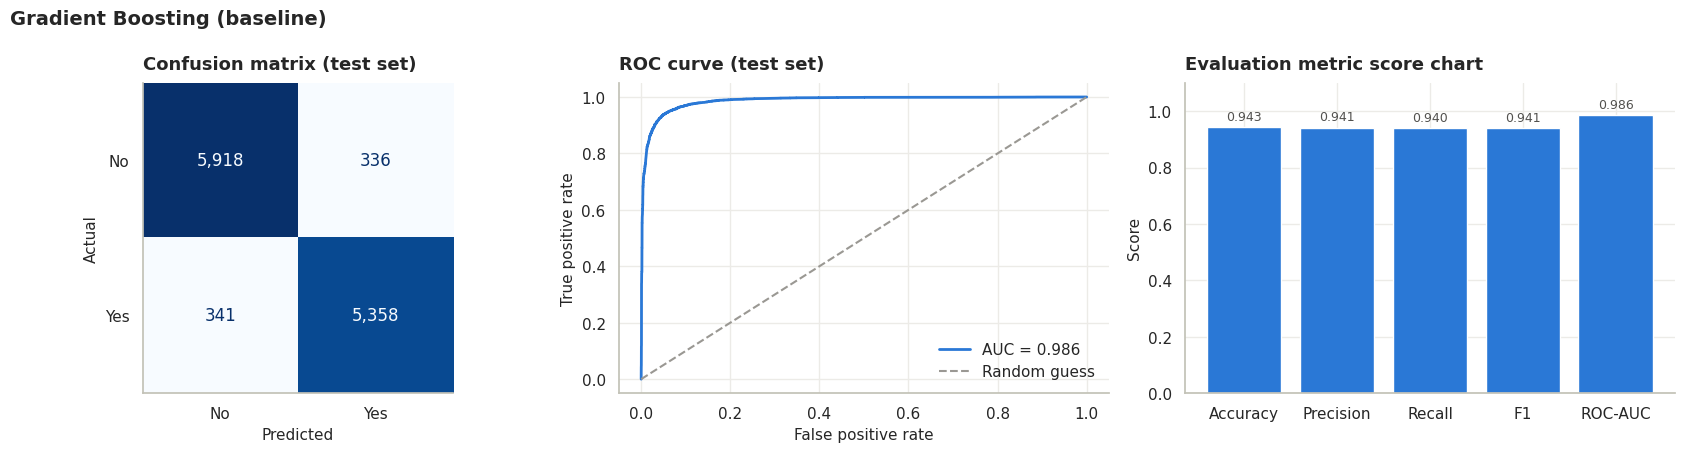

In [ ]:
# ML Model - 3 Implementation (Gradient Boosting)
gb = Pipeline([
    ('prep', build_preprocessor(NUM_FEATURES, CAT_FEATURES, scale=False)),
    ('model', HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
])
gb.fit(X_train, y_train)
gb_cv = cv_score(gb, X_train, y_train)
evaluate_model('Gradient Boosting (baseline)', gb, X_train, y_train, X_test, y_test);

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.


**Performance (test set):** accuracy **0.943**, precision **0.941**, recall **0.940**, F1 **0.941**, ROC-AUC **0.986** (CV F1 0.936).

**Over-fitting check:** training F1 0.941 vs test F1 0.941 - **no over-fitting**.

**Confusion matrix:** 336 detractors wrongly predicted as promoters and 341 promoters missed - the lowest number of false positives of the three baselines.

**Interpretation:** Gradient Boosting matches Logistic Regression and beats Random Forest. The fact that a flexible non-linear model barely improves on a linear one tells us the relationship between ratings and recommendation is **mostly simple and monotonic** ("higher ratings -> more likely to recommend").


## **SECTION 15 — Model Comparison**

**What:** compare the three baseline models on the same test set. **Why:** to choose which model(s) to tune, using F1 and ROC-AUC as the main criteria (and the train-test gap to detect over-fitting).

                                Accuracy  Precision  Recall     F1  ROC-AUC  Train F1  Train-Test F1 gap
Gradient Boosting (baseline)      0.9434     0.9410  0.9402 0.9406   0.9862    0.9412             0.0006
Logistic Regression (baseline)    0.9426     0.9383  0.9416 0.9399   0.9850    0.9360            -0.0039
Random Forest (baseline)          0.9364     0.9344  0.9321 0.9332   0.9820    0.9850             0.0518


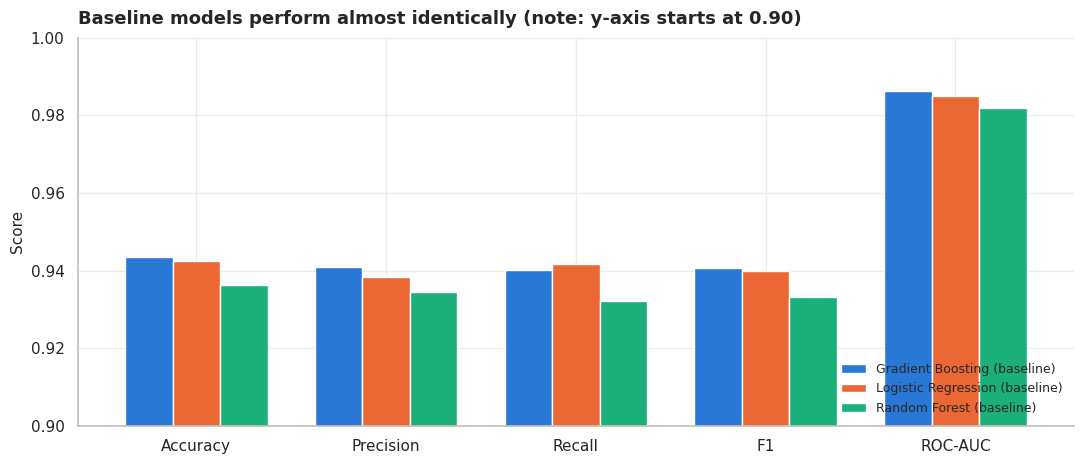

In [ ]:
baseline_names = ['Logistic Regression (baseline)', 'Random Forest (baseline)', 'Gradient Boosting (baseline)']
baseline_table = compare_models(baseline_names)
baseline_table['Train-Test F1 gap'] = (baseline_table['Train F1'] - baseline_table['F1']).round(4)
print(baseline_table.to_string(float_format='{:.4f}'.format))

fig, ax = plt.subplots(figsize=(11, 4.8))
baseline_table[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].T.plot(kind='bar', color=SERIES[:3], ax=ax, width=0.75, edgecolor='white')
ax.set_ylim(0.90, 1.0)
ax.tick_params(axis='x', rotation=0)
ax.legend(frameon=False, loc='lower right', fontsize=9)
finish(ax, 'Baseline models perform almost identically (note: y-axis starts at 0.90)', '', 'Score', legend=True)
plt.tight_layout(); plt.show()


**Interpretation:**
- **Gradient Boosting (F1 0.9406, AUC 0.9862)** and **Logistic Regression (F1 0.9399, AUC 0.9850)** are practically tied; the difference is less than 0.001 in F1.
- **Random Forest** is clearly behind (F1 0.9332) and is the only model with a meaningful train-test gap (0.052), i.e., it over-fits.
- All three have ROC-AUC above 0.98, meaning they rank passengers from most to least likely to recommend very reliably.

**Business implication:** the drivers of recommendation are captured well by a simple model. The two best models (Logistic Regression for interpretability, Gradient Boosting for performance) are taken forward to tuning.


### 15.1 Benchmark: does the overall rating dominate the prediction?

**What:** retrain Logistic Regression and Gradient Boosting with three feature sets: (a) the main service-based features, (b) `overall` alone, (c) service features + `overall`. **Why:** to measure directly how much `overall` adds - and whether a model built only on actionable service ratings loses much accuracy.

In [ ]:
# Benchmark experiment on the same train/test split
feature_sets = {
    'Service features (main model)': (NUM_FEATURES, CAT_FEATURES),
    'Overall rating only':            (['overall'], []),
    'Service features + overall':     (NUM_FEATURES + ['overall'], CAT_FEATURES),
}
bench_rows = []
for set_name, (num_cols, cat_cols) in feature_sets.items():
    for model_name, estimator, scale in [('Logistic Regression', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), True),
                                         ('Gradient Boosting', HistGradientBoostingClassifier(random_state=RANDOM_STATE), False)]:
        transformers = [('num', Pipeline([('impute', SimpleImputer(strategy='median', add_indicator=True))] +
                                         ([('scale', StandardScaler())] if scale else [])), num_cols)]
        if cat_cols:
            transformers.append(('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols))
        pipe = Pipeline([('prep', ColumnTransformer(transformers)), ('model', estimator)])
        pipe.fit(X_train_full[num_cols + cat_cols], y_train)
        pred = pipe.predict(X_test_full[num_cols + cat_cols])
        prob = pipe.predict_proba(X_test_full[num_cols + cat_cols])[:, 1]
        bench_rows.append({'Feature set': set_name, 'Model': model_name, 'Accuracy': accuracy_score(y_test, pred),
                           'F1': f1_score(y_test, pred), 'ROC-AUC': roc_auc_score(y_test, prob)})
benchmark = pd.DataFrame(bench_rows).round(4)
print(benchmark.to_string(float_format='{:.4f}'.format))

                     Feature set                Model  Accuracy     F1  ROC-AUC
0  Service features (main model)  Logistic Regression    0.9426 0.9399   0.9850
1  Service features (main model)    Gradient Boosting    0.9434 0.9406   0.9862
2            Overall rating only  Logistic Regression    0.9572 0.9548   0.9892
3            Overall rating only    Gradient Boosting    0.9572 0.9548   0.9892
4     Service features + overall  Logistic Regression    0.9598 0.9578   0.9927
5     Service features + overall    Gradient Boosting    0.9610 0.9590   0.9927



**Interpretation:**
- **`overall` alone** gives F1 **0.955** and ROC-AUC **0.989** - better than all six service ratings combined (F1 0.941). A single number almost "gives away" the answer.
- Adding `overall` to the service features lifts F1 only to **0.959** (Gradient Boosting) - the service-based model already captures most of the signal.

**Why the main model still excludes `overall`:** it is given at the same moment as the recommendation and is almost a restatement of it; it does not tell IndiGo *which* service area to improve. The service-based model gives up about **2 F1 points** in exchange for being **actionable**. **H4 is confirmed:** the overall rating dominates the prediction.


## **SECTION 16 — Hyperparameter Tuning**

**What:** tune the two most suitable models with cross-validation on the training data:
- **Logistic Regression** with `GridSearchCV` - small search space (regularisation strength `C` and `class_weight`), so every combination can be tried.
- **Gradient Boosting** with `RandomizedSearchCV` - larger search space, so 20 random combinations are tried instead of every combination.

**Why these two:** Logistic Regression is the most interpretable model; Gradient Boosting was the strongest tree model and is fast to train. Random Forest is not tuned further - it performed no better than Gradient Boosting at baseline, showed a larger train-test gap and is several times slower to train.

**Metric optimised:** **F1** (balance of precision and recall), with **5-fold stratified CV**. ROC-AUC is reported as a second check.

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (GridSearchCV)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
lr_grid = GridSearchCV(
    log_reg,
    param_grid={'model__C': [0.01, 0.1, 1, 10], 'model__class_weight': [None, 'balanced']},
    scoring='f1', cv=cv5, n_jobs=-1)
lr_grid.fit(X_train, y_train)
print('Best LR parameters :', lr_grid.best_params_)
print(f'Best LR CV F1      : {lr_grid.best_score_:.4f}')
lr_tuned = lr_grid.best_estimator_
evaluate_model('Logistic Regression (tuned)', lr_tuned, X_train, y_train, X_test, y_test, show=False);

Best LR parameters : {'model__C': 1, 'model__class_weight': 'balanced'}
Best LR CV F1      : 0.9361


In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (RandomizedSearchCV)
gb_search = RandomizedSearchCV(
    gb,
    param_distributions={
        'model__learning_rate': [0.03, 0.05, 0.1, 0.2],
        'model__max_iter': [100, 200, 300],
        'model__max_leaf_nodes': [15, 31, 63],
        'model__min_samples_leaf': [20, 50, 100],
        'model__l2_regularization': [0.0, 0.1, 1.0],
    },
    n_iter=20, scoring='f1', cv=cv5, random_state=RANDOM_STATE, n_jobs=-1)
gb_search.fit(X_train, y_train)
print('Best GB parameters :', gb_search.best_params_)
print(f'Best GB CV F1      : {gb_search.best_score_:.4f}')
gb_tuned = gb_search.best_estimator_
evaluate_model('Gradient Boosting (tuned)', gb_tuned, X_train, y_train, X_test, y_test, show=False);

Best GB parameters : {'model__min_samples_leaf': 100, 'model__max_leaf_nodes': 31, 'model__max_iter': 300, 'model__learning_rate': 0.05, 'model__l2_regularization': 1.0}
Best GB CV F1      : 0.9374


                                Accuracy  Precision  Recall     F1  ROC-AUC  Train F1
Logistic Regression (baseline)    0.9426     0.9383  0.9416 0.9399   0.9850    0.9360
Logistic Regression (tuned)       0.9420     0.9350  0.9440 0.9395   0.9850    0.9363
Gradient Boosting (baseline)      0.9434     0.9410  0.9402 0.9406   0.9862    0.9412
Gradient Boosting (tuned)         0.9439     0.9409  0.9416 0.9412   0.9863    0.9409


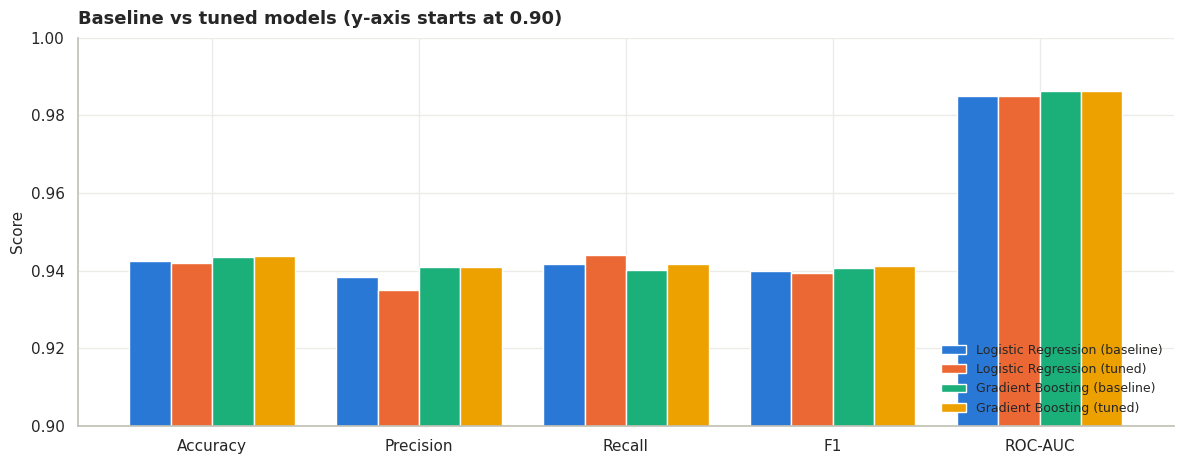

In [ ]:
# Baseline vs tuned - updated evaluation metric score chart
tuning_names = ['Logistic Regression (baseline)', 'Logistic Regression (tuned)',
                'Gradient Boosting (baseline)', 'Gradient Boosting (tuned)']
tuning_table = pd.DataFrame(RESULTS).T.loc[tuning_names].round(4)
print(tuning_table.to_string(float_format='{:.4f}'.format))

fig, ax = plt.subplots(figsize=(12, 4.8))
tuning_table[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].T.plot(kind='bar', color=SERIES[:4], ax=ax, width=0.8, edgecolor='white')
ax.set_ylim(0.90, 1.0)
ax.tick_params(axis='x', rotation=0)
ax.legend(frameon=False, loc='lower right', fontsize=9)
finish(ax, 'Baseline vs tuned models (y-axis starts at 0.90)', '', 'Score', legend=True)
plt.tight_layout(); plt.show()

##### Which hyperparameter optimization technique have you used and why?
- **GridSearchCV** for Logistic Regression: only 8 combinations, so an exhaustive search is cheap and guarantees the best of them is found.
- **RandomizedSearchCV** for Gradient Boosting: 324 possible combinations; trying 20 random ones is far cheaper and usually finds a near-optimal setting.
- Both use **5-fold stratified cross-validation on the training set only**, so the test set remains untouched for the final, unbiased evaluation.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

| Model | Test F1 before -> after | ROC-AUC before -> after | CV F1 before -> after | Best parameters |
|---|---|---|---|---|
| Logistic Regression | 0.9399 -> 0.9395 | 0.9850 -> 0.9850 | 0.9359 -> 0.9361 | `C=1`, `class_weight='balanced'` |
| Gradient Boosting | 0.9406 -> **0.9412** | 0.9862 -> **0.9863** | 0.9364 -> **0.9374** | `learning_rate=0.05`, `max_iter=300`, `max_leaf_nodes=31`, `min_samples_leaf=100`, `l2_regularization=1.0` |

- **Logistic Regression:** no real improvement - the default settings were already optimal; `class_weight='balanced'` changes almost nothing because the classes are already balanced (it slightly raises recall and lowers precision).
- **Gradient Boosting:** a **small but consistent improvement** in both CV F1 (+0.001) and test F1 (+0.0006). The best setting uses a lower learning rate with more trees and larger leaves - a more conservative model that generalises slightly better.
- **Honest conclusion:** tuning gives only marginal gains because the baseline models were already close to the limit of what these features can predict. The remaining ~6% of errors come from genuinely mixed reviews (e.g., good ratings but "no"), not from model settings.


## **SECTION 17 — Final Model Evaluation**


**What:** select the final model and evaluate it in full on the untouched test set.

### Which ML model did you choose from the above created models as your final prediction model and why?
**Tuned Gradient Boosting.** It has the best cross-validation F1 (0.9374), the best test F1 (0.9412) and ROC-AUC (0.9863), the fewest false positives at baseline, and **no over-fitting** (train F1 0.941 = test F1 0.941). Logistic Regression is a very close second and is kept as the **interpretation model**: its coefficients show the direction of each effect, and Section 18 shows both models agree on the key drivers.

### Which Evaluation metrics did you consider for a positive business impact and why?
- **F1-score (primary):** balances precision and recall. Both errors are costly - missing a promoter wastes referral opportunities; calling a detractor a promoter means an unhappy passenger is not contacted for service recovery.
- **ROC-AUC:** shows how well the model *ranks* passengers by likelihood to recommend, which is what a CRM team needs to prioritise outreach.
- **Precision and recall separately + the confusion matrix:** let IndiGo pick a probability threshold that fits each business use (Section 17.1).
- **Accuracy** is reported but not relied on alone; it is meaningful here only because the classes are balanced.


===== Final model - Gradient Boosting (tuned) =====
              precision    recall  f1-score   support

      No (0)      0.947     0.946     0.946      6254
     Yes (1)      0.941     0.942     0.941      5699

    accuracy                          0.944     11953
   macro avg      0.944     0.944     0.944     11953
weighted avg      0.944     0.944     0.944     11953



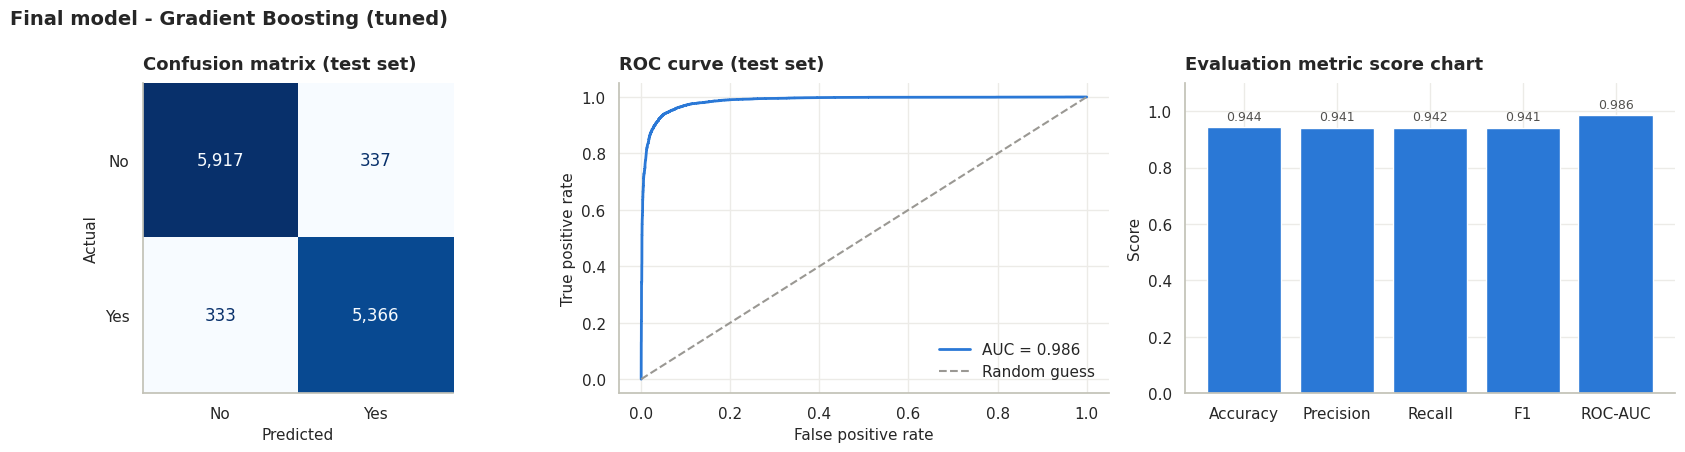

In [ ]:
# Final model - full evaluation on the untouched test set
final_model = gb_tuned
final_name = 'Final model - Gradient Boosting (tuned)'
evaluate_model(final_name, final_model, X_train, y_train, X_test, y_test);

### 17.1 Choosing the decision threshold

**What:** by default a passenger is predicted "Yes" if the probability is at least 0.5. **Why look at other thresholds:** different business uses need different trade-offs. For a **service-recovery** programme (contacting likely detractors), IndiGo may prefer a higher threshold for "Yes" so fewer unhappy passengers are wrongly labelled as promoters.

In [ ]:
# Precision / recall / F1 at different probability thresholds
final_prob = final_model.predict_proba(X_test)[:, 1]
rows = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred_t = (final_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()
    rows.append({'threshold': t, 'precision': precision_score(y_test, pred_t), 'recall': recall_score(y_test, pred_t),
                 'F1': f1_score(y_test, pred_t), 'detractors wrongly called promoters (FP)': fp,
                 'promoters missed (FN)': fn})
threshold_table = pd.DataFrame(rows).round(4)
threshold_table

,threshold,precision,recall,F1,detractors wrongly called promoters (FP),promoters missed (FN)
0,0.300,0.910,0.965,0.937,543,201
1,0.400,0.925,0.953,0.939,439,266
2,0.500,0.941,0.942,0.941,337,333
3,0.600,0.952,0.925,0.939,264,425
4,0.700,0.962,0.906,0.933,204,535



**Interpretation:**
- At the default threshold (0.5) the model is balanced: **337** detractors are wrongly called promoters and **333** promoters are missed out of 11,953 test reviews.
- Raising the threshold to **0.7** cuts the wrongly-called promoters to **204** (precision 0.962) at the cost of missing more promoters (535).
- Lowering it to **0.3** finds 96.5% of promoters (recall) but labels 543 detractors as promoters.

**Business implication:** for a **service-recovery** programme (catch unhappy passengers), use a higher threshold for "Yes" (e.g., 0.6-0.7) so fewer detractors slip through. For a **referral campaign** (find as many promoters as possible), use a lower threshold (e.g., 0.4). F1 stays between 0.933 and 0.941 across this range, so the model is robust to the choice.


### 17.2 Save the final model and reload it for a sanity check (deployment readiness)

In [ ]:
# Save the File
MODEL_PATH = 'indigo_recommendation_model.joblib'
joblib.dump(final_model, MODEL_PATH)
print('Saved:', MODEL_PATH)

Saved: indigo_recommendation_model.joblib


In [ ]:
# Load the File and predict unseen data.
loaded_model = joblib.load(MODEL_PATH)
# Two illustrative passengers (made-up inputs, not from the dataset): an unhappy and a happy economy traveller
new_passengers = pd.DataFrame([
    {'seat_comfort': 2, 'cabin_service': 2, 'food_bev': 2, 'entertainment': np.nan, 'ground_service': 1,
     'value_for_money': 2, 'review_year': 2019, 'traveller_type': 'Business', 'cabin': 'Economy Class'},
    {'seat_comfort': 4, 'cabin_service': 5, 'food_bev': 3, 'entertainment': np.nan, 'ground_service': 4,
     'value_for_money': 5, 'review_year': 2019, 'traveller_type': 'Solo Leisure', 'cabin': 'Economy Class'},
])[FEATURES]
new_passengers['P(recommend)'] = loaded_model.predict_proba(new_passengers)[:, 1].round(3)
new_passengers['Prediction'] = np.where(loaded_model.predict(new_passengers[FEATURES]) == 1, 'Yes', 'No')
print('Reloaded model gives identical test predictions:', (loaded_model.predict(X_test) == final_model.predict(X_test)).all())
new_passengers

Reloaded model gives identical test predictions: True


,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,review_year,traveller_type,cabin,P(recommend),Prediction
0,2,2,2,NaN,1,2,2019,Business,Economy Class,0.010,No
1,4,5,3,NaN,4,5,2019,Solo Leisure,Economy Class,0.994,Yes


## **SECTION 18 — Feature Importance & Explainability**

**What:** explain *which* inputs drive the predictions using three complementary views:
1. **Logistic Regression coefficients** - direction and size of each feature's effect (features are standardised, so coefficients are comparable).
2. **Permutation importance** on the final model - how much the test F1 drops when one feature's values are randomly shuffled. This is model-agnostic and measured on unseen data.
3. **The `overall` benchmark** - how much the overall rating dominates when it is allowed in.

**Why not SHAP:** SHAP is not part of the project's library list and is not needed here - the coefficient and permutation views already give a clear, consistent ranking that is easy to explain.

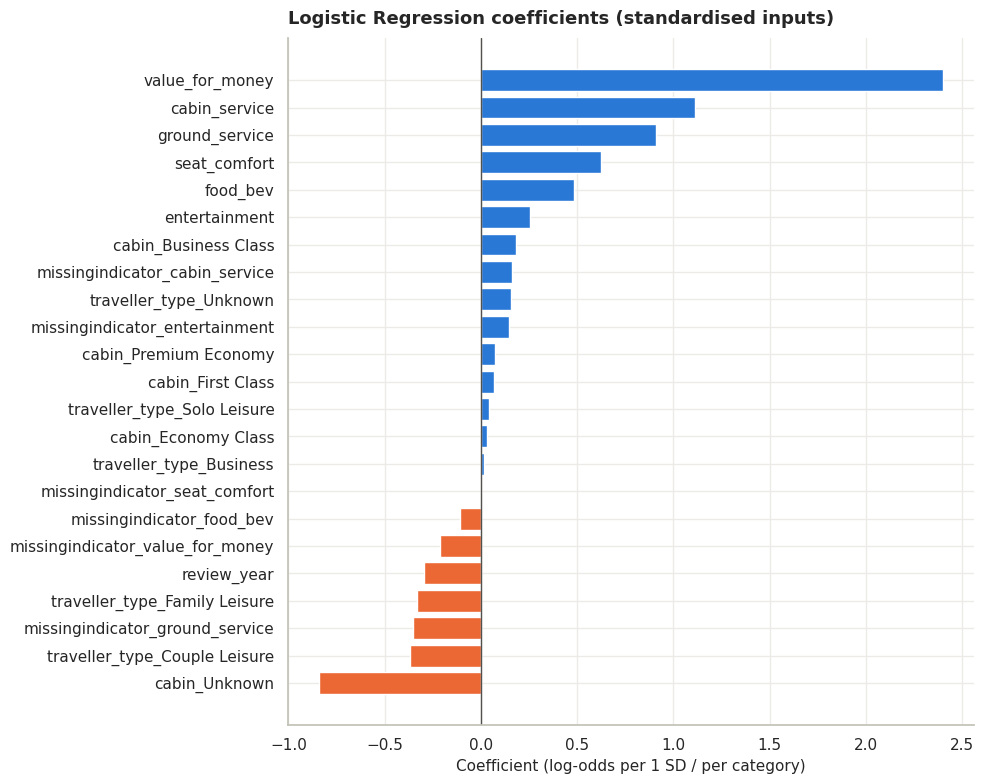

,coefficient,odds_ratio
value_for_money,2.400,11.026
cabin_service,1.113,3.043
ground_service,0.908,2.479
seat_comfort,0.624,1.865
food_bev,0.482,1.620
entertainment,0.253,1.288
cabin_Business Class,0.183,1.201
missingindicator_cabin_service,0.164,1.178
traveller_type_Unknown,0.159,1.173
missingindicator_entertainment,0.147,1.158


In [ ]:
# 18.1 Logistic Regression coefficients (tuned model)
lr_prep, lr_est = lr_tuned.named_steps['prep'], lr_tuned.named_steps['model']
coef = pd.Series(lr_est.coef_[0], index=[n.replace('num__', '').replace('cat__', '') for n in lr_prep.get_feature_names_out()])
coef_df = pd.DataFrame({'coefficient': coef, 'odds_ratio': np.exp(coef)}).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(coef_df.index, coef_df['coefficient'], color=[YES_COLOR if c > 0 else NO_COLOR for c in coef_df['coefficient']])
ax.axvline(0, color=MUTED, linewidth=1)
finish(ax, 'Logistic Regression coefficients (standardised inputs)', 'Coefficient (log-odds per 1 SD / per category)', '')
plt.tight_layout(); plt.show()
display(coef_df.sort_values('coefficient', ascending=False).round(3))


**Interpretation (inputs are standardised, so coefficients are comparable; odds ratio = e^coefficient per one standard deviation, roughly 1.5 rating points):**
- **Value for money** has by far the largest coefficient (**2.40**, odds ratio **11.0**): a one-standard-deviation increase multiplies the odds of recommending by about 11, holding other ratings constant.
- Next are **cabin service (1.11; OR 3.0)**, **ground service (0.91; OR 2.5)**, **seat comfort (0.62; OR 1.9)** and **food & beverage (0.48; OR 1.6)**. **Entertainment** is smallest (0.25; OR 1.3).
- **Couple Leisure (-0.37)** and **Family Leisure (-0.33)** travellers are less likely to recommend than other travellers with the same ratings; **review_year (-0.30)** is negative - later reviews are less positive for the same ratings.
- **cabin = Unknown (-0.84)** is strongly negative: reviews with no cabin recorded are much less likely to recommend (27.0% in the EDA).
- Missing-value indicators have small effects in both directions, reflecting how the review form changed over time.

**Caution:** because the ratings are correlated with each other, individual coefficients should be read as "association holding the other ratings constant", not as exact causal effects.


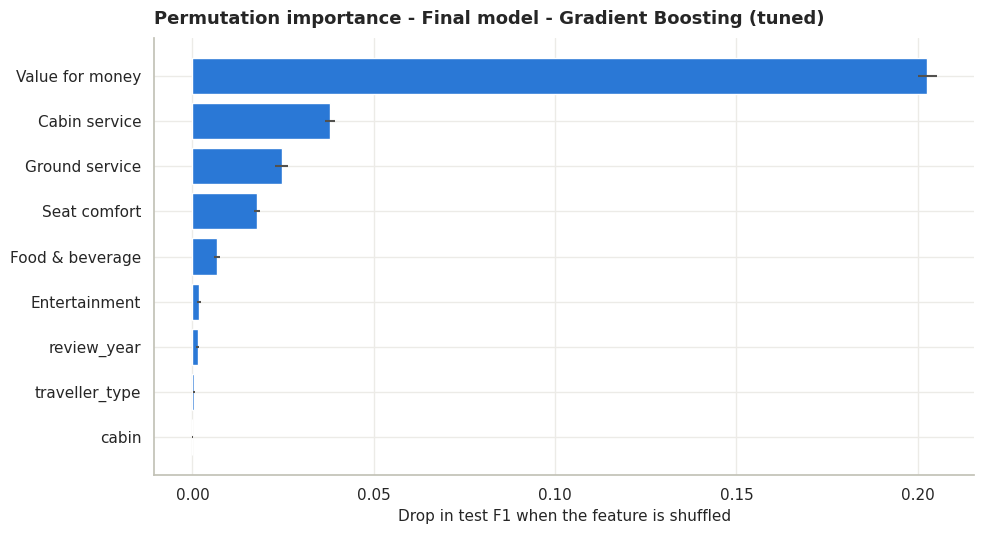

,mean_drop_in_F1,std
value_for_money,0.203,0.003
cabin_service,0.038,0.001
ground_service,0.025,0.002
seat_comfort,0.018,0.001
food_bev,0.007,0.001
entertainment,0.002,0.001
review_year,0.001,0.000
traveller_type,0.001,0.000
cabin,0.000,0.000


In [ ]:
# 18.2 Permutation importance of the final model on the test set (original columns)
perm = permutation_importance(final_model, X_test, y_test, scoring='f1', n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_df = (pd.DataFrame({'mean_drop_in_F1': perm.importances_mean, 'std': perm.importances_std}, index=X_test.columns)
             .sort_values('mean_drop_in_F1'))
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh([RATING_LABELS.get(i, i) for i in perm_df.index], perm_df['mean_drop_in_F1'], xerr=perm_df['std'], color=PRIMARY, ecolor=MUTED)
finish(ax, f'Permutation importance - {final_name}', 'Drop in test F1 when the feature is shuffled', '')
plt.tight_layout(); plt.show()
display(perm_df.sort_values('mean_drop_in_F1', ascending=False).round(4))


**Interpretation:** shuffling **value for money** reduces the final model's test F1 by **0.203** - far more than any other feature. Next are **cabin service (0.038)**, **ground service (0.025)** and **seat comfort (0.018)**; **food & beverage (0.007)** and **entertainment (0.002)** add little once the other ratings are known, and **review year, traveller type and cabin** contribute almost nothing (<= 0.001).

The ranking is the **same as the Logistic Regression coefficients** - two very different models agree, which makes the conclusion robust.

**Why value for money is so dominant:** it is a summary judgement ("was the trip worth what I paid?") that already absorbs part of the other experiences. Because ratings are correlated, when one is shuffled the model can partly recover the information from the others - so the smaller importances of correlated features (e.g., seat comfort vs cabin service) should not be over-interpreted.


In [ ]:
# 18.3 Does the overall rating dominate? Permutation importance when 'overall' is included
gb_overall = Pipeline([
    ('prep', build_preprocessor(NUM_FEATURES + ['overall'], CAT_FEATURES, scale=False)),
    ('model', HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
]).fit(X_train_full[FEATURES + ['overall']], y_train)
perm_o = permutation_importance(gb_overall, X_test_full[FEATURES + ['overall']], y_test, scoring='f1',
                                n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_o_df = pd.Series(perm_o.importances_mean, index=FEATURES + ['overall']).sort_values()
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh([RATING_LABELS.get(i, i) for i in perm_o_df.index], perm_o_df.values,
        color=[HIGHLIGHT if i == 'overall' else PRIMARY for i in perm_o_df.index])
finish(ax, 'When "overall" is allowed in, it dominates the model', 'Drop in test F1 when the feature is shuffled', '')
plt.tight_layout(); plt.show()
print(perm_o_df.sort_values(ascending=False).round(4))


**Interpretation:** when `overall` is allowed in, shuffling it reduces F1 by **0.307**, while value for money drops to **0.015** and every other feature to **0.003 or less**. The model then relies almost entirely on the overall rating. **Yes - the overall rating dominates the prediction**, which is exactly why it was kept out of the main, actionable model.


### 18.4 Importance-Performance view for IndiGo

**What:** combine *how important* each service area is (permutation importance from the final model) with *how IndiGo performs* on it relative to the industry average. **Why:** this classic Importance-Performance Analysis tells management where to **fix**, where to **protect** and where **not to over-invest**.

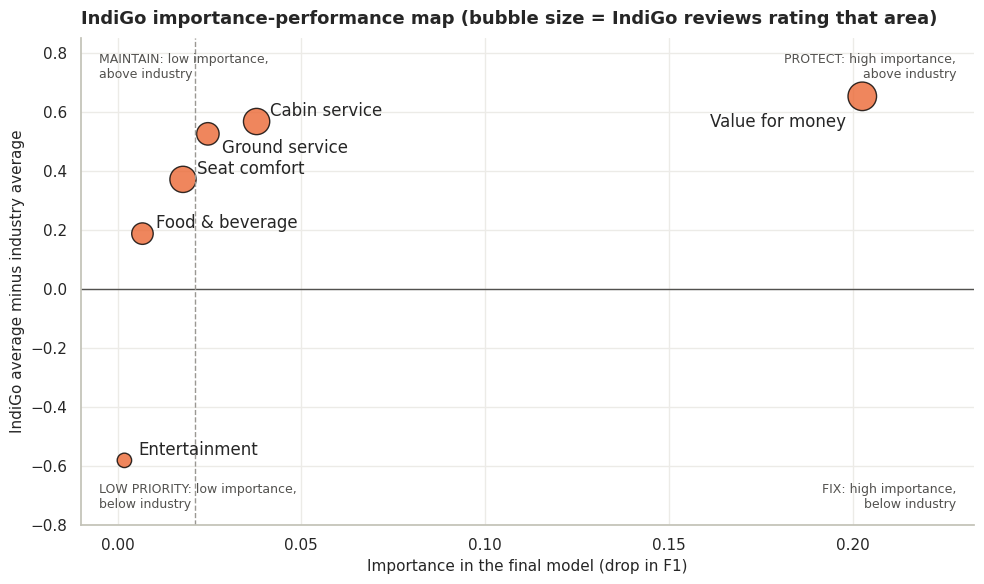

,importance,indigo_minus_industry,indigo_avg,indigo_rated_n
value_for_money,0.203,0.652,3.603,262
cabin_service,0.038,0.567,3.767,219
ground_service,0.025,0.525,3.206,155
seat_comfort,0.018,0.371,3.330,218
food_bev,0.007,0.187,3.114,140
entertainment,0.002,-0.580,2.308,52


In [ ]:
# Importance (x) vs IndiGo performance gap (y) for each service attribute
indigo_all = model_df[model_df['airline'] == 'IndiGo']
ipa = pd.DataFrame({
    'importance': perm_df.loc[RATING_COLS, 'mean_drop_in_F1'],
    'indigo_minus_industry': indigo_all[RATING_COLS].mean() - model_df[RATING_COLS].mean(),
    'indigo_avg': indigo_all[RATING_COLS].mean(),
    'indigo_rated_n': indigo_all[RATING_COLS].count(),
})
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(ipa['importance'], ipa['indigo_minus_industry'], s=ipa['indigo_rated_n'] * 1.5 + 30, color=HIGHLIGHT, alpha=0.8, edgecolor='black')
label_offsets = {'ground_service': (10, -14), 'value_for_money': (-12, -22)}
for col, row in ipa.iterrows():
    ax.annotate(RATING_LABELS[col], (row['importance'], row['indigo_minus_industry']), xytext=label_offsets.get(col, (10, 4)),
                textcoords='offset points', ha='right' if col == 'value_for_money' else 'left')
ax.axhline(0, color=MUTED, linewidth=1)
ax.axvline(ipa['importance'].median(), color=NEUTRAL, linestyle='--', linewidth=1)
ax.set_xlim(-0.01, ipa['importance'].max() * 1.15)
ax.set_ylim(-0.8, 0.85)
quadrants = [(0.98, 0.97, 'PROTECT: high importance,\nabove industry', 'right', 'top'),
             (0.98, 0.03, 'FIX: high importance,\nbelow industry', 'right', 'bottom'),
             (0.02, 0.03, 'LOW PRIORITY: low importance,\nbelow industry', 'left', 'bottom'),
             (0.02, 0.97, 'MAINTAIN: low importance,\nabove industry', 'left', 'top')]
for x, y_, text, ha, va in quadrants:
    ax.text(x, y_, text, transform=ax.transAxes, ha=ha, va=va, fontsize=9, color=MUTED)
finish(ax, 'IndiGo importance-performance map (bubble size = IndiGo reviews rating that area)',
       'Importance in the final model (drop in F1)', 'IndiGo average minus industry average')
plt.tight_layout(); plt.show()
display(ipa.sort_values('importance', ascending=False).round(3))


**Interpretation:**
- **Protect (high importance, IndiGo above industry):** **value for money** (+0.65 vs industry) and **cabin service** (+0.57) are both the most important drivers *and* IndiGo strengths. **Ground service** (+0.53) and **seat comfort** (+0.37) are also above average and near the importance cut-off.
- **Maintain:** food & beverage (+0.19) - modest importance, slightly above industry.
- **Low priority:** entertainment is IndiGo's only below-average area (-0.58) but has the **lowest importance** of all services; it is also rated in only 52 IndiGo reviews.
- **No service area falls in the "Fix" quadrant** (high importance, below industry).

**Business implication:** IndiGo's job is mainly to **defend its existing advantages** - keep fares and fees perceived as fair, and keep cabin-crew and airport service consistent - rather than invest heavily in in-flight entertainment.


### Answers to the explainability questions

| Question | Answer (with evidence) |
|---|---|
| **What drives customer recommendations?** | Mainly how passengers rate **value for money**, then **cabin service**, **ground service** and **seat comfort** (permutation importance 0.203 / 0.038 / 0.025 / 0.018; same order in Logistic Regression coefficients) |
| **Which service areas should IndiGo prioritise?** | Protect value for money and cabin service (most important and already strengths); keep ground service and seat comfort above industry average |
| **Does value for money matter?** | Yes - it is the single strongest driver (odds ratio 11.0 per SD; 0.9% vs 98.1% recommendation at ratings 1 vs 5; r = 0.98 across airlines) |
| **How important is cabin service?** | Second most important (odds ratio 3.0 per SD; recommendation rate 2.0% at rating 1 vs 93.5% at 5) |
| **How important is ground service?** | Third most important (odds ratio 2.5 per SD); it has the most 1-ratings (40%) across the industry, so it is a frequent pain point |
| **Does food/entertainment influence recommendations?** | Only modestly. Food & beverage has a small effect (OR 1.6); entertainment has the smallest effect of all services (OR 1.3; permutation importance 0.002) |
| **Does overall trip rating dominate the prediction?** | Yes. Alone it reaches F1 0.955; with it in the model it accounts for almost all importance (0.307 vs 0.015 for the next feature). It is excluded from the main model because it is almost a restatement of the target and is not actionable |


## **SECTION 19 — Business Insights**

Each insight follows **Finding -> Evidence -> Business implication -> Recommended action**. The model shows **association and predictive importance, not proven cause and effect**; actions should be piloted and measured.

| # | Finding | Evidence | Business implication | Recommended action |
|---|---|---|---|---|
| 1 | **Value for money is the strongest driver of recommendation** | Highest permutation importance (0.203) and LR odds ratio (11.0 per SD); 0.9% recommend at rating 1 vs 98.1% at 5; r = 0.98 between airline value score and recommendation rate | Perceived value - not just a low fare - decides advocacy. Hidden fees or poor service can destroy it (see Spirit and Frontier at the bottom of Chart 12) | Keep pricing transparent (clear baggage/seat fees); track a "value for money" question in post-flight surveys as a lead KPI; use value messaging in marketing |
| 2 | **Cabin service is the second biggest lever** | Importance 0.038; OR 3.0; IndiGo's cabin service is +0.57 above industry (3.77 vs 3.20) | Crew behaviour is a key differentiator that IndiGo already does well | Protect it: continue crew training and recognition; feature crew service in campaigns |
| 3 | **Ground service is an industry pain point and an IndiGo strength** | Importance 0.025; OR 2.5; 40% of all ground-service ratings are 1; IndiGo +0.53 above industry | Check-in, boarding and baggage problems are a common reason for negative reviews | Maintain airport process KPIs (queue time, on-time boarding, baggage delivery); prioritise ground-service recovery |
| 4 | **The overall rating almost equals the recommendation** | Overall alone: F1 0.955; recommendation 94%+ at 7 or above | Overall score is a great outcome KPI but not a diagnostic tool | Use overall (or NPS-style) scores to monitor, and service ratings to diagnose |
| 5 | **Entertainment matters least** | Lowest importance (0.002) and OR (1.3); IndiGo's only below-average rating (2.31 vs 2.89, n=52) | Spending heavily on in-flight entertainment is unlikely to move recommendation much on short-haul economy flights | Low-cost options only (e.g., streaming to personal devices) if justified by cost; do not prioritise |
| 6 | **Economy is the hardest cabin; IndiGo is 100% Economy** | Economy 43.5% recommend vs Business 66.6%; Economy is the lowest or near-lowest cabin for every traveller type | IndiGo competes in the most difficult segment and must win on consistency and value rather than luxury | Focus improvements on economy pain points (seat comfort, ground process, fair fees) |
| 7 | **Couples, families and business travellers in economy are least positive** | Business travellers in economy: 32.5%; couples in economy: 32.6%; Couple and Family Leisure have negative coefficients | These are large, high-value segments with room to improve | Targeted offers: family seating and boarding, business-traveller benefits (priority check-in, flexible changes) |
| 8 | **Solo leisure travellers are the most positive segment** | 49.3% recommend (highest stated type); 75.8-76.1% in premium cabins | Natural promoters for word-of-mouth | Referral and review-invitation campaigns aimed at solo leisure travellers who rate value and service 4+ |
| 9 | **Recommendation is declining across the industry** | Recommendation rate fell from 53.1% (2016) to 31.0% (2019); negative review-year coefficient | Passengers are becoming harder to satisfy (or more critical reviewers are posting) | Track recommendation over time as a board-level KPI; benchmark IndiGo vs competitors yearly |
| 10 | **The model can flag likely detractors** | Test F1 0.941, ROC-AUC 0.986; the threshold can be tuned (Section 17.1) | Unhappy passengers can be identified from survey ratings alone | Score post-flight surveys; route low-probability passengers to service recovery (apology, voucher) and high-probability passengers to referral programmes |

## **SECTION 20 — Limitations**

1. **Multi-airline data, few IndiGo reviews.** Only 262 of 59,761 reviews are about IndiGo; IndiGo-specific averages are less precise, and drivers learned from all airlines may differ slightly for IndiGo's domestic, short-haul network.
2. **Self-selected online reviews.** Reviewers are not a random sample of passengers - very happy and very unhappy passengers are more likely to write reviews (seen in the polarised ratings).
3. **Association, not causation.** The model shows which ratings *predict* recommendation; it does not prove that raising a rating will cause more recommendations. Ratings are given at the same time as the recommendation and are likely influenced by the passenger's overall mood ("halo effect").
4. **Correlated predictors.** Service ratings are correlated (0.61-0.79), so individual importances, especially for similar attributes, should be interpreted with care.
5. **Systematic missing data.** Several fields only exist in reviews from about 2015 onwards; median imputation with indicators handles this, but older and newer reviews are not perfectly comparable.
6. **Information not used.** Review text, route, aircraft and flight date were not modelled (out of scope / mostly missing), and there is no data on delays, fares, loyalty status or demographics.
7. **Time period.** Reviews end in mid-2019; patterns may have changed after 2019 (e.g., post-pandemic travel).

## **SECTION 21 — Final Conclusion**

# **Conclusion**

**Best-performing model:** the **tuned Gradient Boosting classifier** (test accuracy 0.944, precision 0.941, recall 0.942, **F1 0.941**, **ROC-AUC 0.986**, no over-fitting). Tuned Logistic Regression is practically as good (F1 0.940, ROC-AUC 0.985) and is used to explain the direction of each effect. Random Forest over-fitted and performed worst.

**Key predictive factors:** **value for money** (by far the most important), then **cabin service**, **ground service** and **seat comfort**. Food & beverage has a small effect; entertainment, traveller type and cabin add little once the service ratings are known. The **overall rating** dominates any model that includes it (F1 0.955 on its own), but it is almost a restatement of the recommendation and is not actionable, so it was used only as a benchmark.

**Business implications for IndiGo:** IndiGo already outperforms the industry on the factors that matter most (value for money, cabin service, ground service), which explains its 65.3% recommendation rate vs 47.7% across all airlines. The priority is to **protect these strengths**, use them in word-of-mouth marketing, and target less positive segments (couples, families and business travellers in economy). Entertainment, IndiGo's only weakness, is the least important driver and a low priority.

**Hypotheses revisited:**
| Hypothesis | Result |
|---|---|
| H1. Value for money is one of the strongest drivers | **Confirmed** - strongest driver in every analysis |
| H2. Business travellers recommend more than leisure travellers | **Not supported** - solo leisure travellers recommend most (49.3% vs 40.3% for business) |
| H3. Cabin service score is a key determinant | **Confirmed** - second most important driver |
| H4. Overall rating almost gives away the answer | **Confirmed** - F1 0.955 on its own; dominates feature importance |
| H5. Premium cabins have higher recommendation rates | **Confirmed** - Business 66.6% and First 62.7% vs Economy 43.5% |

**Suggestions for future analysis:**
- Add **NLP on the review text** (topics and sentiment) to find *why* passengers rate value or service poorly.
- Collect IndiGo's own **post-flight survey data** (with delays, fares and route) to train an IndiGo-specific model.
- Use **SHAP** or partial-dependence analysis for individual-level explanations once deployed.
- Build a **dashboard** that tracks predicted recommendation and the key service ratings by route and month.
- Run **A/B tests** of service changes (e.g., fee transparency) to measure their causal effect on recommendation.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***